# Analyse exploratoire — *Fighting Maternal Risk*

> **Semaine 16 — Évaluation**  
> **Groupe 7 · Akieni Academy**

| Membres du groupe |
|---|
| Pejuce Pedrich NDINGA |
| Theresia Surya NGOUBALI |
| Minervi TULIKUMWE MINDAMUTSA |
| MASUKU Eecha Henri |

---

## Plan du notebook

| # | Section | Contenu |
|---|---|---|
| 1 | Introduction | Cadre, jeu de données, outils, chargement |
| 2 | Exploration des données | Taille, aperçu, valeurs manquantes, anomalies |
| 3 | Nettoyage des données | Corrections et décisions |
| 4 | Analyse des données | Analyses univariée et bivariée |
| 5 | Visualisation des résultats | Graphiques |
| 6 | Conclusion | Résumé, résultats, limites, recommandations |

---

## Contexte

Dans le cadre de notre parcours de formation en Data Science au sein d'Akieni Academy, nous réalisons une analyse exploratoire des facteurs associés aux différents niveaux de risque maternel chez les femmes enceintes.

## Objectif général

Réaliser une analyse exploratoire des données relatives aux femmes enceintes afin de :

- décrire leurs caractéristiques sociodémographiques et physiologiques ;
- étudier leurs relations avec les différents niveaux de risque maternel ;
- mettre en évidence les principales associations observables.

## Problématique

> **Dans quelle mesure les caractéristiques physiologiques et sociodémographiques des femmes enceintes sont-elles associées aux différents niveaux de risque maternel observés dans les données ?**

## Outils

`pandas` · `matplotlib` · `seaborn`


---
# 1. INTRODUCTION

> **Objectif de cette étape**  
> Poser le cadre : de quoi parle-t-on, quelles données a-t-on, quelle question cherche-t-on à éclairer, avec quels outils.

## 1.1 Contexte et question


- **Contexte** : des mesures de santé de femmes enceintes (**âge, tension, glycémie, température, fréquence cardiaque**) et un niveau de risque.
- **Question** : quelles variables sont associées au niveau de risque ?
- **Pourquoi ce projet** : thème de santé maternelle, données tabulaires de taille raisonnable, variables numériques faciles à explorer et à visualiser.

## 1.2 Vue globale des fichiers


| Fichier | Variable pandas | Rôle |
|---|---|---|
| `train.csv` | `df_train` | Données d'entraînement : mesures **+ le niveau de risque** (`RiskLevel`) |
| `test.csv` | `df_test` | Mêmes variables, mais **sans** le niveau de risque |
| `sample_submission.csv` | `df_sample` | Modèle du fichier de réponse attendu (`Id` + `RiskLevel`) |
| `metadata.csv` | `df_metadata` | Dictionnaire des variables (description de chaque colonne) |


## 1.3 Le jeu de données « Fighting Maternal Risk »

Disponible sur **Kaggle** : <https://www.kaggle.com/competitions/mlolympiadbd2025/data>

Il décrit le niveau de risque des femmes enceintes à partir de mesures de santé collectées au **Bangladesh**, dans des établissements de santé tels que des hôpitaux, des centres de santé communautaires et des structures de soins maternels, situés notamment dans les zones rurales.

> **Contexte complémentaire.** La santé maternelle au Bangladesh soulève aussi la question des **grossesses précoces** chez les adolescentes âgées de **10 à 14 ans**. Selon les statistiques historiques de l'enquête démographique de **2011**, le taux de natalité était de **7,25 naissances pour 1 000 filles** de cette tranche d'âge. Une estimation issue de l'enquête de **2017-2018** indiquait **10,48 naissances pour 1 000 filles**. Ces données sont présentées comme provenant de sources liées à **l'OMS et à l'UNICEF**.

## 1.4 Fichier principal de l'analyse : `train.csv`


Notre analyse s'appuie **principalement sur `train.csv`**, puis sur sa version nettoyée `df_train_clean` (809 lignes après suppression de 2 valeurs aberrantes). C'est le seul fichier qui contient à la fois les mesures de santé et le niveau de risque (`RiskLevel`), indispensable pour répondre à notre problématique.

| Fichier | Utilisation dans le notebook | Rôle dans l'analyse |
|---|---|---|
| `train.csv` | Section 2 (exploration), 3 (nettoyage), 4 (analyse) et 5 (graphiques 1 à 8) | **Fichier principal** : toutes les statistiques, corrélations et graphiques portent sur `df_train_clean` |
| `test.csv` | Section 2 et 3 (nettoyage), graphique 8 | Secondaire : sert uniquement à vérifier que `train` et `test` sont comparables. Il ne contient pas `RiskLevel`, on ne peut donc pas y étudier le risque |
| `metadata.csv` | Section 2.1 | Référence : sert à comprendre la signification des variables |
| `sample_submission.csv` | Section 2 | Marginal : sert uniquement à vérifier le format attendu, sans intérêt analytique |


## 1.5 Contrainte et outils


- **Contrainte** : pas de machine learning ; on s'arrête à l'analyse et à la visualisation.
- **Outils** : `pandas` (manipulation des tableaux), `matplotlib` et `seaborn` (graphiques), choisis pour leur simplicité et parce qu'ils suffisent à répondre à la question posée.

## 1.6 Importation des bibliothèques et chargement des fichiers

### Importation des bibliothèques

In [72]:
# On importe les bibliothèques nécessaires
import os 

import pandas as pd                   # pour manipuler les tableaux de données 
import matplotlib.pyplot as plt      # pour faire les graphiques 
import seaborn as sns

# Afficher toutes les colonnes des tableaux 
pd.set_option("display.max_columns", None) 

# Active l'affichage haute résolution des graphiques 
plt.rcParams['figure.dpi'] = 150  # Vous pouvez tester 200 ou 300 pour encore plus de netteté


### Chargement des fichiers

In [40]:

# Chemin vers les données brutes
CHEMIN_DONNEES = "./donnees/brutes/"

# Chargement des datasets
df_train = pd.read_csv(f"{CHEMIN_DONNEES}train.csv")
df_test = pd.read_csv(f"{CHEMIN_DONNEES}test.csv")
df_sample = pd.read_csv(f"{CHEMIN_DONNEES}sample_submission.csv")
df_metadata = pd.read_csv(f"{CHEMIN_DONNEES}metadata.csv")

print("Les fichiers ont été chargés avec succès !")

Les fichiers ont été chargés avec succès !


---

# 2. EXPLORATION DES DONNÉES

> **Objectif de cette étape**  
> Découvrir les données **sans rien modifier** : taille, colonnes, types, premières lignes, signification de chaque variable. On cherche à repérer d'éventuels problèmes, qu'on traitera à l'étape suivante.

**Démarche**

1. Regarder la taille avec `.shape`, les premières lignes avec `.head()`, les types avec `.info()`.
2. Lire le dictionnaire des variables.
3. Comparer `df_train` et `df_test`.
4. Chercher les valeurs manquantes, les doublons et les valeurs bizarres.

**Fonctions pandas à retenir :** `read_csv`, `shape`, `head`, `info`, `describe`, `isna().sum()`, `duplicated()`, `value_counts()`

---

## 2.1 Le dictionnaire des variables : `metadata.csv`

In [41]:
display(df_metadata)

,Column,Description
0,Id,Unique row identifier
1,Age,Age of pregnant woman (years)
2,SystolicBP,Systolic blood pressure (mmHg)
3,DiastolicBP,Diastolic blood pressure (mmHg)
4,Blood glucose,Blood sugar (mmol/L)
5,BodyTemp,Body temperature (°C)
6,HeartRate,Heart rate (bpm)
7,RiskLevel,"Target risk level (Low Risk, Mid Risk, High Risk)"


## 2.2 La taille de chaque tableau
nombre de lignes, nombre de colonnes

In [42]:

print("─" * 50)
print("DIMENSIONS DES DATASETS (LIGNES, COLONNES)")
print("─" * 50)
print("df_train  :\t", df_train.shape)
print("df_test   :\t", df_test.shape) 
print("df_sample :\t", df_sample.shape) 
print("df_metadata :\t", df_metadata.shape)
print("─" * 50)

──────────────────────────────────────────────────
DIMENSIONS DES DATASETS (LIGNES, COLONNES)
──────────────────────────────────────────────────
df_train  :	 (811, 9)
df_test   :	 (203, 8)
df_sample :	 (203, 2)
df_metadata :	 (8, 2)
──────────────────────────────────────────────────


## 2.3 Les premières lignes
*(pour voir à quoi ressemblent les données)*

In [43]:
# Aperçu des datasets

print("─" * 50)
print("APERÇU DES DATASETS")
print("─" * 50)

# df_train
print("\n────────── df_train ──────────")
display(df_train.head())

# df_test
print("\n────────── df_test ──────────")
display(df_test.head())

# df_sample
print("\n────────── df_sample ──────────")
display(df_sample.head())

# df_metadata
print("\n────────── df_metadata ──────────")
display(df_metadata.head())

print("─" * 50)


──────────────────────────────────────────────────
APERÇU DES DATASETS
──────────────────────────────────────────────────

────────── df_train ──────────


,Id,Age,SystolicBP,DiastolicBP,Blood glucose,BodyTemp,HeartRate,RiskLevel,Usage
0,617,31,120,60,6.1,98.0,76,0,Train
1,774,23,120,90,7.8,98.0,60,1,Train
2,610,13,90,65,7.5,101.0,80,2,Train
3,525,42,120,80,7.5,98.0,70,0,Train
4,70,26,85,60,6.0,101.0,86,1,Train



────────── df_test ──────────


,Id,Age,SystolicBP,DiastolicBP,Blood glucose,BodyTemp,HeartRate,Usage
0,71,29,130,70,7.7,98.0,78,Test
1,141,17,90,60,6.9,101.0,76,Test
2,918,50,120,80,7.5,98.0,70,Test
3,491,23,120,90,7.9,98.0,70,Test
4,878,32,120,90,6.8,98.0,70,Test



────────── df_sample ──────────


,Id,RiskLevel
0,71,Low Risk
1,141,Low Risk
2,918,Low Risk
3,491,Low Risk
4,878,Low Risk



────────── df_metadata ──────────


,Column,Description
0,Id,Unique row identifier
1,Age,Age of pregnant woman (years)
2,SystolicBP,Systolic blood pressure (mmHg)
3,DiastolicBP,Diastolic blood pressure (mmHg)
4,Blood glucose,Blood sugar (mmol/L)


──────────────────────────────────────────────────


> **Aperçu des données — observations**
>
> - **Fréquence cardiaque** : la valeur minimale est de **7 battements par minute**, ce qui est impossible.
> - **Température** : `BodyTemp` varie entre `98` et `103` alors que `metadata.csv` annonce des **°C** ; ce sont en réalité des **°F** (correction au nettoyage).

## 2.4 Les valeurs manquantes

In [44]:
print("─" * 50)
print("VALEURS MANQUANTES DANS df_train :")
print("─" * 50)
print(df_train.isnull().sum())
print("─" * 50)
print() 
print("─" * 50)
print("VALEURS MANQUANTES DANS df_test :") 
print("─" * 50)
print(df_test.isnull().sum())
print("─" * 50)

──────────────────────────────────────────────────
VALEURS MANQUANTES DANS df_train :
──────────────────────────────────────────────────
Id               0
Age              0
SystolicBP       0
DiastolicBP      0
Blood glucose    0
BodyTemp         0
HeartRate        0
RiskLevel        0
Usage            0
dtype: int64
──────────────────────────────────────────────────

──────────────────────────────────────────────────
VALEURS MANQUANTES DANS df_test :
──────────────────────────────────────────────────
Id               0
Age              0
SystolicBP       0
DiastolicBP      0
Blood glucose    0
BodyTemp         0
HeartRate        0
Usage            0
dtype: int64
──────────────────────────────────────────────────


## 2.5 La variable à expliquer (`RiskLevel`)

In [45]:
# Répartition des niveaux de risque

print("─" * 50)
print("RÉPARTITION DES NIVEAUX DE RISQUE")
print("─" * 50)

repartition_risque = pd.DataFrame({
    "Niveau de risque": ["Low Risk", "Mid Risk", "High Risk"],
    "df_train": [
        (df_train["RiskLevel"] == 0).sum(),
        (df_train["RiskLevel"] == 1).sum(),
        (df_train["RiskLevel"] == 2).sum()
    ],
    "df_sample": [
        (df_sample["RiskLevel"] == "Low Risk").sum(),
        (df_sample["RiskLevel"] == "Mid Risk").sum(),
        (df_sample["RiskLevel"] == "High Risk").sum()
    ]
})

display(repartition_risque)


──────────────────────────────────────────────────
RÉPARTITION DES NIVEAUX DE RISQUE
──────────────────────────────────────────────────


,Niveau de risque,df_train,df_sample
0,Low Risk,325,203
1,Mid Risk,269,0
2,High Risk,217,0


> **Aperçu des données — observation**
>
> Dans `sample_submission.csv`, toutes les lignes valent **Low Risk**.

## 2.6 Vérifications sur les identifiants, doublons et valeurs suspectes

In [46]:
# les id sont-ils uniques ?
print("─" * 100)
print("RESULTATS DES ANALYSES :")
print("─" * 100)

print("id en double dans train\t\t:", df_train["Id"].duplicated().sum())

# un même id apparaît-il à la fois dans train et test ?
print("id communs train/test\t\t:", len(set(df_train["Id"]) & set(df_test["Id"])))

# test et sample_submission contiennent-ils les mêmes id dans le même ordre ?
ids_identiques = (df_test["Id"].values == df_sample["Id"].values).all()
print(
    "id test = id sample\t\t:",
    "oui, les id sont identiques et dans le même ordre."
    if ids_identiques
    else "non, les id sont différents ou dans un ordre différent."
)


# lignes identiques si on ignore la colonne id
print("lignes identiques (sans id)\t:", df_train.drop(columns="Id").duplicated().sum())

# fréquence cardiaque très basse : les 5 plus petites valeurs
print("les 5 plus petites fréquences cardiaques\t:", df_train["HeartRate"].sort_values().head(5).tolist())


print("─" * 100)

# les valeurs de température
print("─" * 100)
print("valeurs de BodyTemp\t:")
print("─" * 100)

print(df_train["BodyTemp"].value_counts().sort_index())

print("─" * 100)


────────────────────────────────────────────────────────────────────────────────────────────────────
RESULTATS DES ANALYSES :
────────────────────────────────────────────────────────────────────────────────────────────────────
id en double dans train		: 0
id communs train/test		: 0
id test = id sample		: oui, les id sont identiques et dans le même ordre.
lignes identiques (sans id)	: 397
les 5 plus petites fréquences cardiaques	: [7, 7, 60, 60, 60]
────────────────────────────────────────────────────────────────────────────────────────────────────
────────────────────────────────────────────────────────────────────────────────────────────────────
valeurs de BodyTemp	:
────────────────────────────────────────────────────────────────────────────────────────────────────
BodyTemp
98.0     645
98.4       1
98.6       1
99.0       7
100.0     15
101.0     78
102.0     54
103.0     10
Name: count, dtype: int64
───────────────────────────────────────────────────────────────────────────────────

### Bilan de l'exploration

| Constat | Détail |
|---|---|
| **Taille** | `df_train` : 811 lignes · `df_test` : 203 lignes |
| **Valeurs manquantes** | Aucune |
| **Fréquence cardiaque** | 2 valeurs impossibles (**7 bpm**) |
| **Température** | En **°F** alors que le dictionnaire annonce des **°C** |
| **Doublons (hors `Id`)** | Beaucoup de lignes identiques : des mesures très courantes (ex. 120/80) reviennent souvent |
| **Cible** | Niveau de risque codé **0 / 1 / 2** dans `df_train` |

---

# 3. NETTOYAGE DES DONNÉES
> **À quoi sert cette étape ?**  
> Corriger ce qu'on a repéré à l'exploration, pour que les analyses soient fiables.

### Les étapes classiques d'un nettoyage


1. Faire une **copie** des données d'origine (on ne touche jamais à l'original)
2. Supprimer les colonnes inutiles / renommer les colonnes compliquées
3. Traiter les **valeurs manquantes**
4. Traiter les **valeurs aberrantes**
5. Corriger les **unités** et les **types**
6. Décider quoi faire des **doublons**
7. **Vérifier** le résultat

### Décisions prises


| Sujet | Décision |
|---|---|
| **Valeurs manquantes** | Aucune, rien à faire. |
| **Fréquence cardiaque aberrante** (7 bpm) | Suppression des 2 lignes concernées (seuil exploratoire : moins de 40 bpm). |
| **Colonne `Usage`** | Ne contient qu'une seule valeur (`"Train"`), donc supprimée. |
| **Colonne `Blood glucose`** | Renommée `BloodGlucose` (pas d'espace, plus simple à écrire). |
| **Cible** | Ajout d'une colonne `RiskLabel` avec libellés. L'association 0 = Low, 1 = Mid, 2 = High est une **hypothèse** (la glycémie et la tension moyennes augmentent avec le code), pas une information du jeu de données. Des descriptions publiques du jeu d'origine utilisent le même ordre, mais cela reste à confirmer sur la page Kaggle du jeu. |
| **Température** | Ajout de `BodyTemp_C` en supposant que `BodyTemp` est en °F ; la colonne d'origine est conservée. |

---

## 3.1 Copie des données, suppression de `Usage` et renommage d'une colonne

In [47]:
# On travaille sur des copies : df_train et df_test d'origine restent intacts
df_train_clean = df_train.copy() 
df_test_clean  = df_test.copy()

# La colonne "Usage" ne contient que "Train" ou "Test" : elle est inutile pour l'analyse 
df_train_clean = df_train_clean.drop(columns="Usage") 
df_test_clean  = df_test_clean.drop(columns="Usage") 

# "Blood glucose" contient un espace : on le remplace pour écrire du code plus simplement 

df_train_clean = df_train_clean.rename(columns={"Blood glucose": "BloodGlucose"}) 
df_test_clean  = df_test_clean.rename(columns={"Blood glucose": "BloodGlucose"}) 

print("─" * 100)
print("RESULTAT")
print("─" * 100)
print(df_train_clean.columns.tolist())
print("─" * 100)

────────────────────────────────────────────────────────────────────────────────────────────────────
RESULTAT
────────────────────────────────────────────────────────────────────────────────────────────────────
['Id', 'Age', 'SystolicBP', 'DiastolicBP', 'BloodGlucose', 'BodyTemp', 'HeartRate', 'RiskLevel']
────────────────────────────────────────────────────────────────────────────────────────────────────


## 3.2 Valeurs aberrantes

> Une fréquence cardiaque de **7 bpm** est impossible (c'est sûrement une erreur de saisie). On retire ces lignes : il n'y en a que **2 sur 811**, donc on perd très peu d'information.

In [48]:
# On affichage des lignes concernées (fréquence < 40 bpm) 

aberrantes_bpm = df_train_clean[df_train_clean["HeartRate"] < 40] 
display(aberrantes_bpm)

# On garde les lignes avec une fréquence cardiaque >= 40 
df_train_clean = df_train_clean[df_train_clean["HeartRate"] >= 40].copy() 

print("─" * 50)
print("Nombre de lignes après suppression :", len(df_train_clean))
print("─" * 50)

,Id,Age,SystolicBP,DiastolicBP,BloodGlucose,BodyTemp,HeartRate,RiskLevel
41,908,16,120,75,7.9,98.0,7,0
213,499,16,120,75,7.9,98.0,7,0


──────────────────────────────────────────────────
Nombre de lignes après suppression : 809
──────────────────────────────────────────────────


## 3.3 Correction de l'unité : °F → °C

Les valeurs (98 à 103) sont des degrés **Fahrenheit**. On crée une nouvelle colonne en °C avec la formule :

$$°C = (°F - 32) \times \frac{5}{9}$$

In [49]:
df_train_clean["BodyTemp_C"] = ((df_train_clean["BodyTemp"] - 32) * 5 / 9).round(1) 
df_test_clean["BodyTemp_C"]  = ((df_test_clean["BodyTemp"]  - 32) * 5 / 9).round(1) 

# Vérification : 98°F doit donner environ 36,7°C

df_train_clean[["BodyTemp", "BodyTemp_C"]].drop_duplicates().sort_values("BodyTemp")

,BodyTemp,BodyTemp_C
0,98.0,36.7
782,98.4,36.9
605,98.6,37.0
100,99.0,37.2
53,100.0,37.8
2,101.0,38.3
40,102.0,38.9
25,103.0,39.4


## 3.4 Rendre le niveau de risque lisible

Dans `df_train`, le risque est codé 0, 1, 2. On crée une colonne avec du texte pour que les tableaux et les graphiques soient plus clairs.

> **Hypothèse**
>
> - `metadata.csv` ne donne pas la correspondance chiffre ↔ texte.
> - On prend **0 = Low Risk**, **1 = Mid Risk**, **2 = High Risk**.
> - Cohérence avec les données : la glycémie et la tension moyennes augmentent avec le chiffre (voir section 4).

In [50]:
correspondance = {0: "Low Risk", 1: "Mid Risk", 2: "High Risk"} 
df_train_clean["RiskLabel"] = df_train_clean["RiskLevel"].map(correspondance)

# Ordre d'affichage qu'on réutilisera partout 
ordre = ["Low Risk", "Mid Risk", "High Risk"] 
df_train_clean[["RiskLevel", "RiskLabel"]].drop_duplicates().sort_values("RiskLevel")

,RiskLevel,RiskLabel
0,0,Low Risk
1,1,Mid Risk
2,2,High Risk


## 3.5 Les doublons

> Les lignes « identiques » ont des `Id` différents : ce sont des patientes différentes qui ont par hasard les mêmes mesures (surtout des valeurs très courantes comme 120/80).  
> **On les garde**, sinon on perdrait environ la moitié des données.

In [51]:
nb_doublons = df_train_clean.drop(columns="Id").duplicated().sum()
print("Lignes identiques (hors Id) :", nb_doublons, "sur", len(df_train_clean))  

Lignes identiques (hors Id) : 396 sur 809


## 3.6 Vérification finale du nettoyage

In [52]:
# 3.6 Vérification finale du nettoyage 

df_train_clean = df_train_clean.reset_index(drop=True)  

print("Taille df_train_clean :", df_train_clean.shape) 
print("Taille df_test_clean  :", df_test_clean.shape) 
print() 
print("Valeurs manquantes (df_train) :", df_train_clean.isnull().sum().sum())
print("Valeurs manquantes (df_test)  :", df_test_clean.isnull().sum().sum())
print() 
df_train_clean.describe().round(2)

Taille df_train_clean : (809, 10)
Taille df_test_clean  : (203, 8)

Valeurs manquantes (df_train) : 0
Valeurs manquantes (df_test)  : 0



,Id,Age,SystolicBP,DiastolicBP,BloodGlucose,BodyTemp,HeartRate,RiskLevel,BodyTemp_C
count,809.00,809.00,809.00,809.00,809.00,809.00,809.00,809.00,809.00
mean,498.61,29.95,113.09,76.29,8.66,98.67,74.28,0.87,37.06
std,291.51,13.50,18.46,13.82,3.21,1.37,7.58,0.81,0.75
min,0.00,10.00,70.00,49.00,6.00,98.00,60.00,0.00,36.70
25%,250.00,19.00,100.00,65.00,6.90,98.00,70.00,0.00,36.70
50%,498.00,26.00,120.00,80.00,7.50,98.00,76.00,1.00,36.70
75%,745.00,38.00,120.00,90.00,8.00,98.00,80.00,2.00,36.70
max,1012.00,70.00,160.00,100.00,19.00,103.00,90.00,2.00,39.40


## 3.7 Sauvegarde des données nettoyées

> Les données nettoyées sont enregistrées dans le dossier `donnees/traitees/`, à côté des données brutes (`donnees/brutes/`). Elles pourront être rechargées directement dans les prochains notebooks, sans refaire le nettoyage.

In [53]:
# Chemin vers les données traitées
CHEMIN_TRAITEES = "./donnees/traitees/"

# Création du dossier s'il n'existe pas
os.makedirs(CHEMIN_TRAITEES, exist_ok=True)

# Sauvegarde des datasets nettoyés (sans l'index)
df_train_clean.to_csv(f"{CHEMIN_TRAITEES}train_clean.csv", index=False)
df_test_clean.to_csv(f"{CHEMIN_TRAITEES}test_clean.csv", index=False)

print("─" * 50)
print("SAUVEGARDE DES DONNÉES NETTOYÉES")
print("─" * 50)
print("train_clean.csv :", df_train_clean.shape)
print("test_clean.csv  :", df_test_clean.shape)
print("Dossier         :", CHEMIN_TRAITEES)
print("─" * 50)


──────────────────────────────────────────────────
SAUVEGARDE DES DONNÉES NETTOYÉES
──────────────────────────────────────────────────
train_clean.csv : (809, 10)
test_clean.csv  : (203, 8)
Dossier         : ./donnees/traitees/
──────────────────────────────────────────────────


### Bilan du nettoyage

- 2 lignes aberrantes supprimées → **809 lignes** dans `df_train_clean`
- Colonne `Usage` supprimée, `Blood glucose` renommée `BloodGlucose`
- Température convertie en °C (`BodyTemp_C`)
- Niveau de risque traduit en texte (`RiskLabel`)
- Doublons conservés (`Id` différents)
- Données nettoyées enregistrées dans `donnees/traitees/` (`train_clean.csv` et `test_clean.csv`)


---

# 4. ANALYSE DES DONNÉES

> **À quoi sert cette étape ?**  
> Transformer les données brutes en informations utiles pour comprendre une situation et aider à la prise de décision.  
> **Question :** *dans quelle mesure les caractéristiques physiologiques et sociodémographiques des femmes enceintes sont-elles associées aux différents niveaux de risque maternel observés dans les données ?*


### Les outils pandas à retenir


| Besoin | Outil |
|---|---|
| Compter / proportions | `value_counts()` |
| Comparer des groupes | `groupby(...).mean()` |
| Mesurer le lien entre variables | `.corr()` |
| Croiser deux variables | `pd.crosstab(...)` |
| Découper en classes | `pd.cut(...)` |

---


### Liste des variables étudiées

In [54]:
# Liste des variables numériques qu'on va étudier (on la réutilisera)
variables = ["Age", "SystolicBP", "DiastolicBP", "BloodGlucose", "BodyTemp_C", "HeartRate"]
variables

['Age', 'SystolicBP', 'DiastolicBP', 'BloodGlucose', 'BodyTemp_C', 'HeartRate']

## 4.1 Analyse univariée

L'**analyse univariée** consiste à analyser une seule variable à la fois pour comprendre sa distribution et ses caractéristiques.

**Étape 1 : le niveau de risque maternel (variable cible)**  
**Objectif :** déterminer les effectifs et les proportions de chaque niveau de risque maternel.

### Répartition des niveaux de risque (en %)

In [55]:
repartition_niveau_risque = df_train_clean["RiskLabel"].value_counts(normalize=True) * 100
repartition_niveau_risque = repartition_niveau_risque.reindex(ordre).round(1)
display(repartition_niveau_risque)

RiskLabel
Low Risk     39.9
Mid Risk     33.3
High Risk    26.8
Name: proportion, dtype: float64

> **Analyse**
>
> Dans l'ensemble des femmes enceintes enregistrées (**809 individus**) :
>
> | Niveau | Libellé | Proportion |
> |:---:|---|:---:|
> | 0 | Low Risk | **39,9 %** *(la plus élevée)* |
> | 1 | Mid Risk | **33,3 %** |
> | 2 | High Risk | **26,8 %** *(la plus faible)* |
>
> **En conclusion :** le niveau de risque **0** est le plus représenté, suivi du niveau **1**, puis du niveau **2**, le moins fréquent.
 

## 4.2 Analyse bivariée

L'**analyse bivariée** consiste à étudier la relation entre deux variables. L’objectif est de déterminer s’il existe une association, une différence ou une corrélation entre elles.

**Étape 1 : moyenne de chaque mesure selon le niveau de risque**

In [56]:
moyenne_par_niveau_risque = (
    df_train_clean
    .groupby("RiskLabel")[variables]
    .mean()
    .round(2)
)

moyenne_par_niveau_risque = moyenne_par_niveau_risque.reindex(ordre)

moyenne_par_niveau_risque


,Age,SystolicBP,DiastolicBP,BloodGlucose,BodyTemp_C,HeartRate
RiskLabel,,,,,,
Low Risk,27.06,105.70,72.49,7.24,36.89,73.05
Mid Risk,28.11,112.99,74.04,7.71,37.16,74.15
High Risk,36.52,124.20,84.76,11.95,37.19,76.28


> **Conclusion**
>
> **1. Observation** : les valeurs moyennes augmentent lorsque le niveau de risque augmente. Les personnes à faible risque ont les moyennes les plus faibles.
>
> - Risque moyen : les moyennes augmentent légèrement.
> - Risque élevé : les moyennes sont plus importantes, surtout pour l'âge, la pression artérielle et la glycémie.
>
> **2. Conclusion** : les variables étudiées semblent être associées au niveau de risque. Plus le risque est élevé, plus certaines caractéristiques présentent des valeurs moyennes élevées.

## 4.3 Médiane de chaque mesure selon le niveau de risque

In [57]:
# (la médiane est moins sensible aux valeurs extrêmes)

mediane_par_niveau_risque  = df_train_clean.groupby("RiskLabel")[variables].median().round(2)
mediane_par_niveau_risque  = mediane_par_niveau_risque .reindex(ordre)
mediane_par_niveau_risque 

,Age,SystolicBP,DiastolicBP,BloodGlucose,BodyTemp_C,HeartRate
RiskLabel,,,,,,
Low Risk,23.0,120.0,75.0,7.5,36.7,70.0
Mid Risk,25.0,120.0,75.0,7.0,36.7,76.0
High Risk,35.0,130.0,90.0,11.0,36.7,77.0


> **Interprétation des médianes**
>
> Les médianes sont **proches entre Low Risk et Mid Risk** : les pressions systolique (120) et diastolique (75) sont identiques, la température est la même (36,7 °C) et la glycémie médiane est même un peu plus basse en Mid Risk (7,0) qu'en Low Risk (7,5). La **rupture se fait au niveau High Risk**, surtout pour l'âge (35 ans), la pression diastolique (90) et la **glycémie (11,0)**, qui montre l'écart le plus marqué.

## 4.4 Corrélation avec le niveau de risque

> La corrélation est un nombre entre **−1** et **+1** : proche de **0** = pas de lien ; proche de **+1** = quand l'une augmente, l'autre aussi.

In [58]:
colonnes_corr = variables + ["RiskLevel"]

matrice_correlations = (
    df_train_clean[colonnes_corr]
    .corr()
    .round(2)
)

correlation_avec_risque = (
    matrice_correlations["RiskLevel"]
    .drop("RiskLevel")
    .sort_values(ascending=False)
)

print("La corrélation de chaque variable avec RiskLevel (de la plus forte à la plus faible) :")
correlation_avec_risque


La corrélation de chaque variable avec RiskLevel (de la plus forte à la plus faible) :


BloodGlucose    0.56
SystolicBP      0.40
DiastolicBP     0.34
Age             0.27
BodyTemp_C      0.17
HeartRate       0.17
Name: RiskLevel, dtype: float64

> **Interprétation**
>
> **Corrélations avec `RiskLevel`**
>
> | Variable | Corrélation | Force du lien |
> |---|:---:|---|
> | `BloodGlucose` | **0.56** | modérée-forte |
> | `SystolicBP` | **0.40** | modérée |
> | `DiastolicBP` | **0.34** | modérée |
> | `Age` | **0.27** | faible-modérée |
> | `BodyTemp_C` | **0.17** | faible |
> | `HeartRate` | **0.17** | faible |
>
> La glycémie est le facteur le plus fortement corrélé au niveau de risque, suivie de la pression artérielle. L'âge montre une corrélation plus faible mais non négligeable. La température et la fréquence cardiaque ont peu d'influence.
>
> **Corrélations entre variables**
>
> - `SystolicBP` et `DiastolicBP` : **0.79** (forte corrélation attendue)
> - Autres corrélations inter-variables : faibles à modérées

## 4.5 La glycémie découpée en classes, croisée avec le risque
*(en % de chaque ligne)*

In [59]:
# pd.cut découpe une variable en classes : (0-7], (7-9], (9-12], (12-20]

classes = [0, 7, 9, 12, 20]
noms    = ["7 ou moins", "7 à 9", "9 à 12", "Plus de 12"]
df_train_clean["GlycemieClasse"] = pd.cut(df_train_clean["BloodGlucose"], bins=classes, labels=noms)

tableau_glycemie = pd.crosstab(df_train_clean["GlycemieClasse"], df_train_clean["RiskLabel"], normalize="index") * 100
tableau_glycemie = tableau_glycemie[ordre].round(1)
tableau_glycemie

RiskLabel,Low Risk,Mid Risk,High Risk
GlycemieClasse,,,
7 ou moins,41.7,50.5,7.8
7 à 9,56.2,25.5,18.2
9 à 12,7.3,21.8,70.9
Plus de 12,0.0,10.6,89.4


> **Interprétation**
>
> | Glycémie (mmol/L) | Low Risk | Mid Risk | High Risk |
> |---|:---:|:---:|:---:|
> | ≤ 7 | 41.7 % | 50.5 % | 7.8 % |
> | 7 à 9 | 56.2 % | 25.5 % | 18.2 % |
> | 9 à 12 | 7.3 % | 21.8 % | **70.9 %** |
> | > 12 | 0 % | 10.6 % | **89.4 %** |
>
> Le risque ne croît pas régulièrement avec la glycémie : la classe « 7 ou moins » contient davantage de Mid Risk (50.5 %) que de Low Risk (41.7 %). En revanche, le seuil de **9 mmol/L** apparaît comme un **point de bascule** : au-delà, la majorité des femmes sont classées à haut risque. Une glycémie > 12 mmol/L est quasi-exclusivement associée au haut risque (89.4 %).

## 4.6 La tension systolique élevée (≥ 140 mmHg), croisée avec le risque

In [60]:
df_train_clean["TensionElevee"] = df_train_clean["SystolicBP"] >= 140

tableau_tension = pd.crosstab(df_train_clean["TensionElevee"], df_train_clean["RiskLabel"], normalize="index") * 100
tableau_tension = tableau_tension[ordre].round(1)
tableau_tension.index = ["Tension < 140", "Tension >= 140"]
tableau_tension

RiskLabel,Low Risk,Mid Risk,High Risk
Tension < 140,45.8,37.4,16.7
Tension >= 140,0.0,4.8,95.2


> **Interprétation**
>
> | Tension systolique | Low Risk | Mid Risk | High Risk |
> |---|:---:|:---:|:---:|
> | < 140 mmHg | 45.8 % | 37.4 % | 16.7 % |
> | ≥ 140 mmHg | 0 % | 4.8 % | **95.2 %** |
>
> L'hypertension (≥ 140 mmHg) est un indicateur quasi-exclusif de haut risque (95.2 %). Aucune femme hypertensive n'est classée à faible risque, confirmant l'importance clinique de ce seuil.

---

# 5. VISUALISATION DES RÉSULTATS

> **À quoi sert cette étape ?**  
> Transformer les chiffres en graphiques pour voir les différences d'un coup d'œil.

### Choix des graphiques ?


| Pour montrer... | Graphique | Fonction |
|---|---|---|
| Une répartition de catégories | Diagramme en barres | `plt.bar()` |
| La forme d'une variable numérique | Histogramme | `plt.hist()` |
| Comparer une variable entre groupes | Boîte à moustaches | `plt.boxplot()` |
| Le lien entre 2 variables | Nuage de points | `plt.scatter()` |
| Une table de corrélations | Carte de chaleur | `sns.heatmap()` |  


> **NB :** chaque graphique a un titre, des axes nommés, et se termine par `plt.show()`.

---

### Définition de la palette des couleurs

In [61]:
# Une couleur par niveau de risque (on les réutilise dans tous les graphiques)
couleurs = {"Low Risk": "#4CAF50", "Mid Risk": "#FFB300", "High Risk": "#E53935"} 

### Création du dossier d'exportation des figures

In [62]:

# création du dossier figures s'il n'existe pas
os.makedirs("./figures", exist_ok=True)

## 5.1 Graphique 1 : Répartition des niveaux de risque

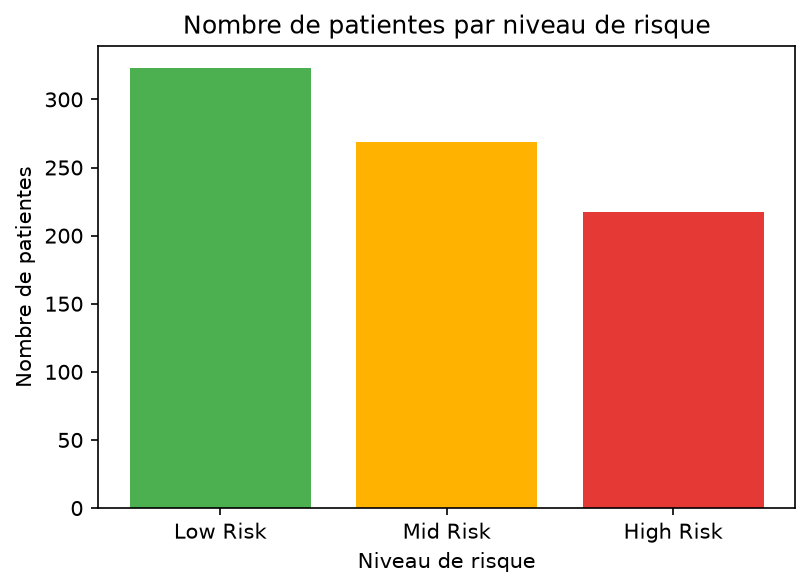

In [73]:

comptage = df_train_clean["RiskLabel"].value_counts().reindex(ordre)

plt.figure(figsize=(6, 4))
plt.bar(
    comptage.index,
    comptage.values,
    color=[couleurs[r] for r in comptage.index]
)

plt.title("Nombre de patientes par niveau de risque")
plt.xlabel("Niveau de risque")
plt.ylabel("Nombre de patientes")

# sauvegarde de la figure
plt.savefig("./figures/repartition_niveaux_risque.png", dpi=600, bbox_inches="tight")

plt.show()
plt.close()


## 5.2 Graphique 2 : Distribution de chaque mesure
*(histogrammes)*

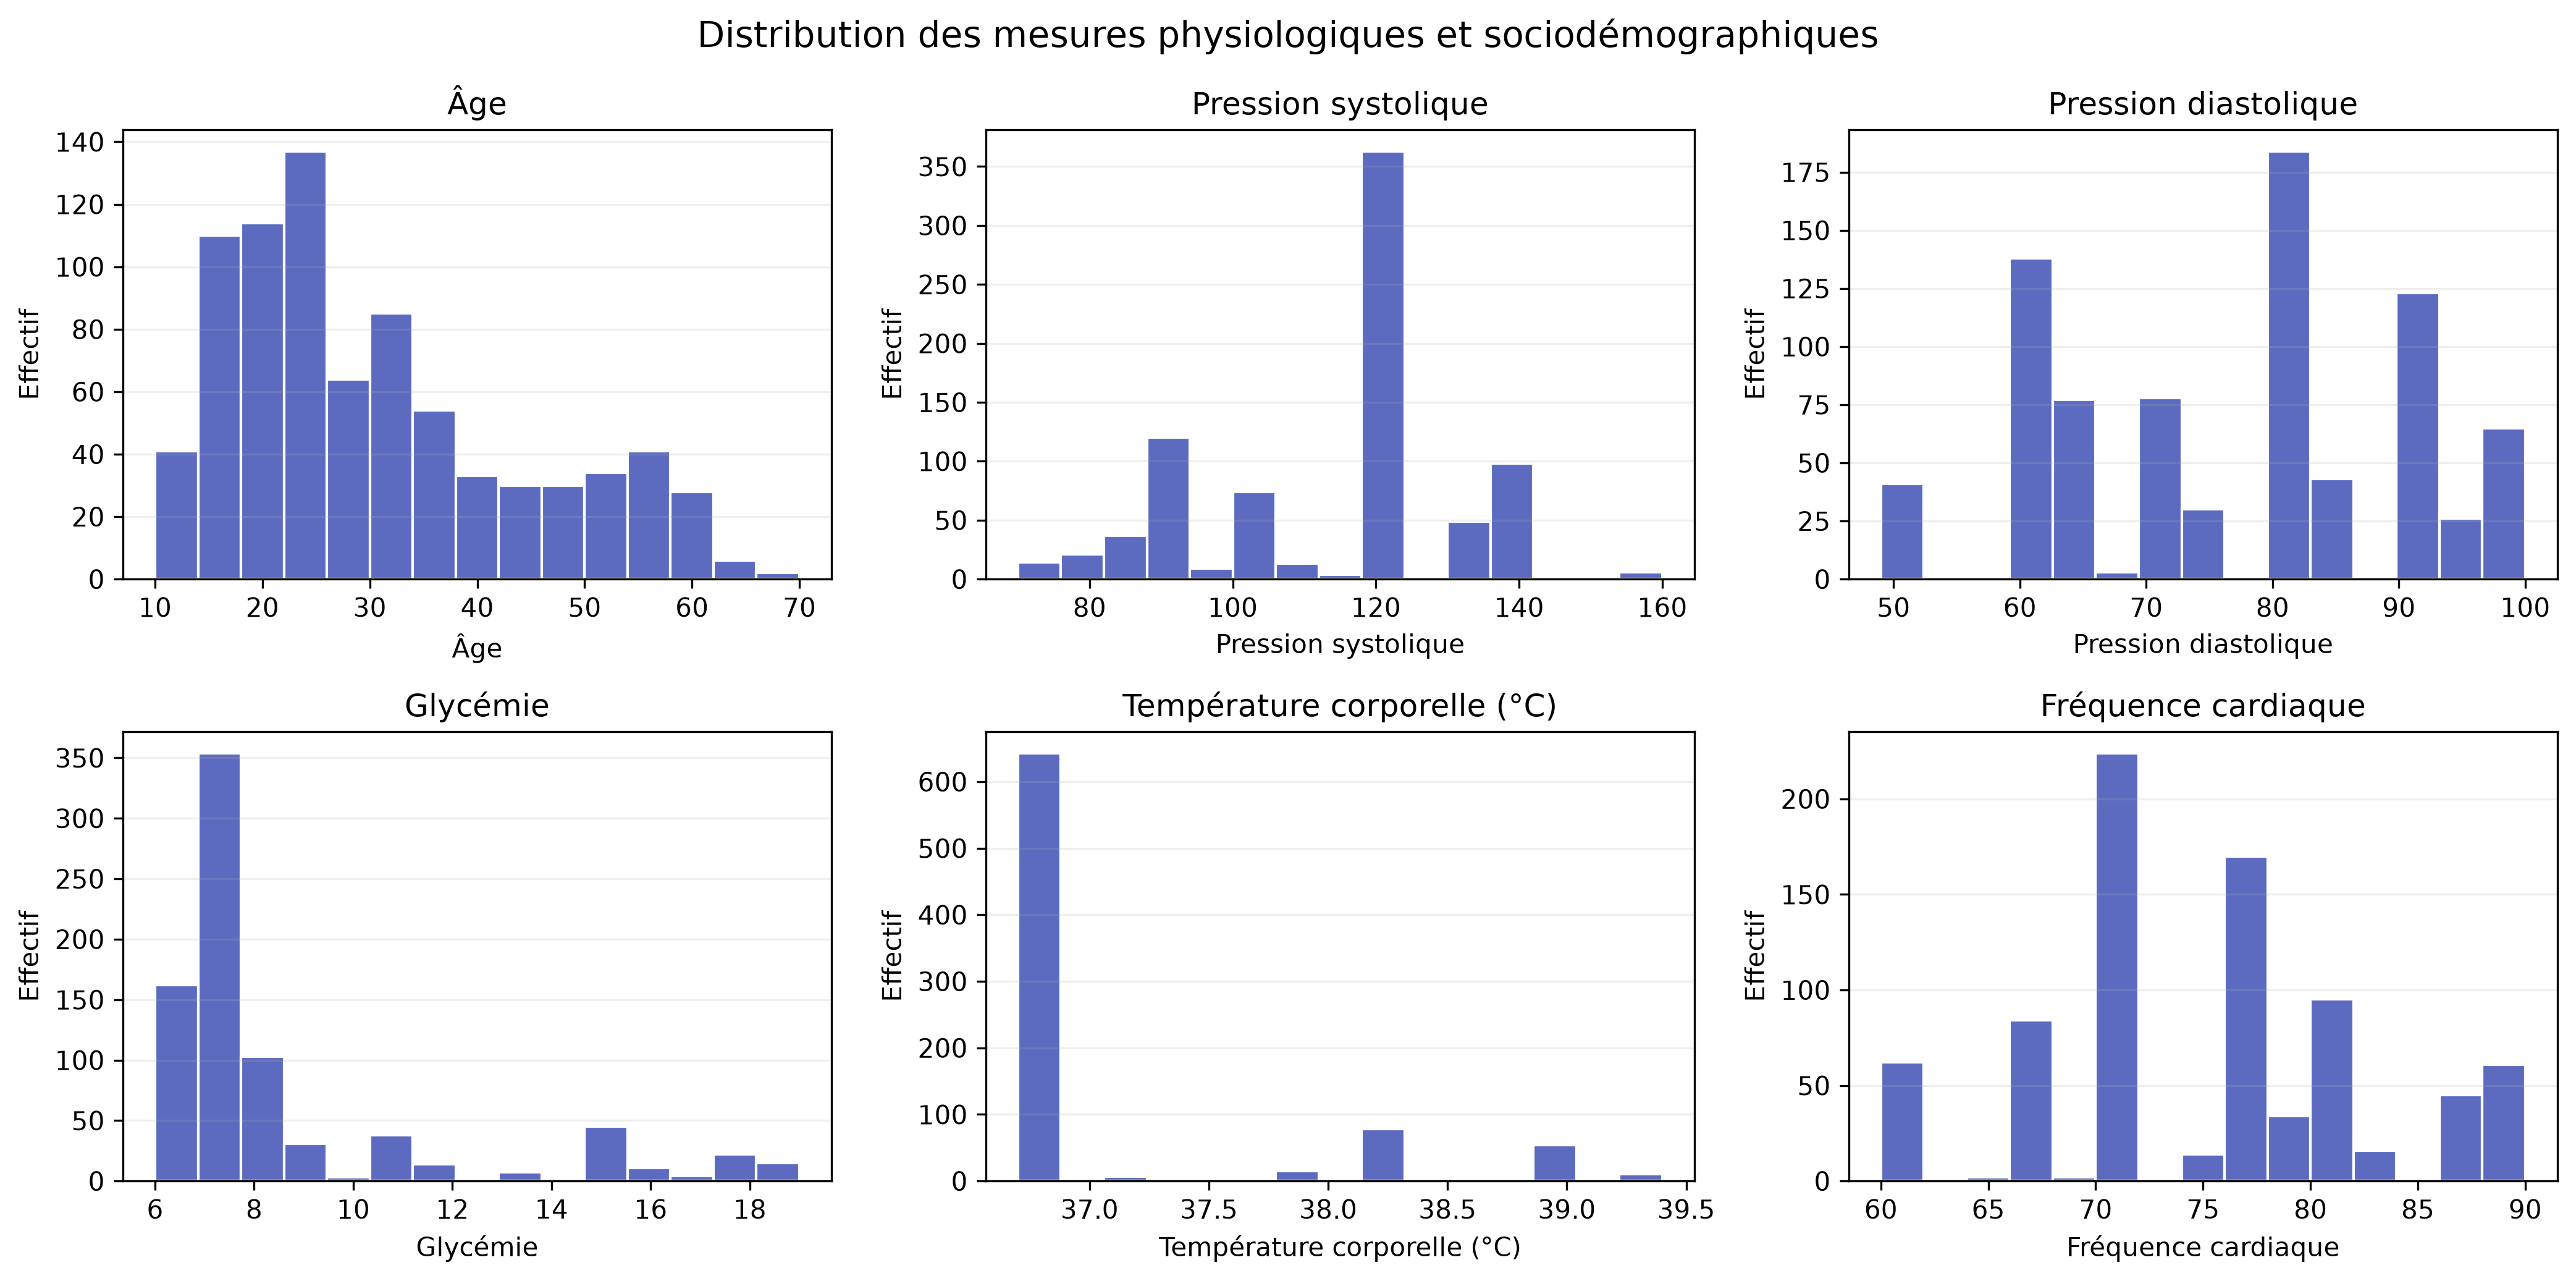

In [64]:
# définition des variables numériques à analyser
mesures = [
    "Age",
    "SystolicBP",
    "DiastolicBP",
    "BloodGlucose",
    "BodyTemp_C",
    "HeartRate"
]

# noms affichés sur les graphiques
noms_mesures = [
    "Âge",
    "Pression systolique",
    "Pression diastolique",
    "Glycémie",
    "Température corporelle (°C)",
    "Fréquence cardiaque"
]

# création des graphiques
fig, axes = plt.subplots(2, 3, figsize=(14, 7))

axes = axes.flatten()

for i, colonne in enumerate(mesures):
    axes[i].hist(
        df_train_clean[colonne],
        bins=15,
        color="#5C6BC0",
        edgecolor="white"
    )
    axes[i].set_title(noms_mesures[i])
    axes[i].set_xlabel(noms_mesures[i])
    axes[i].set_ylabel("Effectif")
    axes[i].grid(axis="y", alpha=0.2)

plt.suptitle(
    "Distribution des mesures physiologiques et sociodémographiques",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    "./figures/distribution_mesures.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()
plt.close()


## 5.3 Graphique 3 : Chaque mesure selon le niveau de risque
*(boîtes à moustaches)*

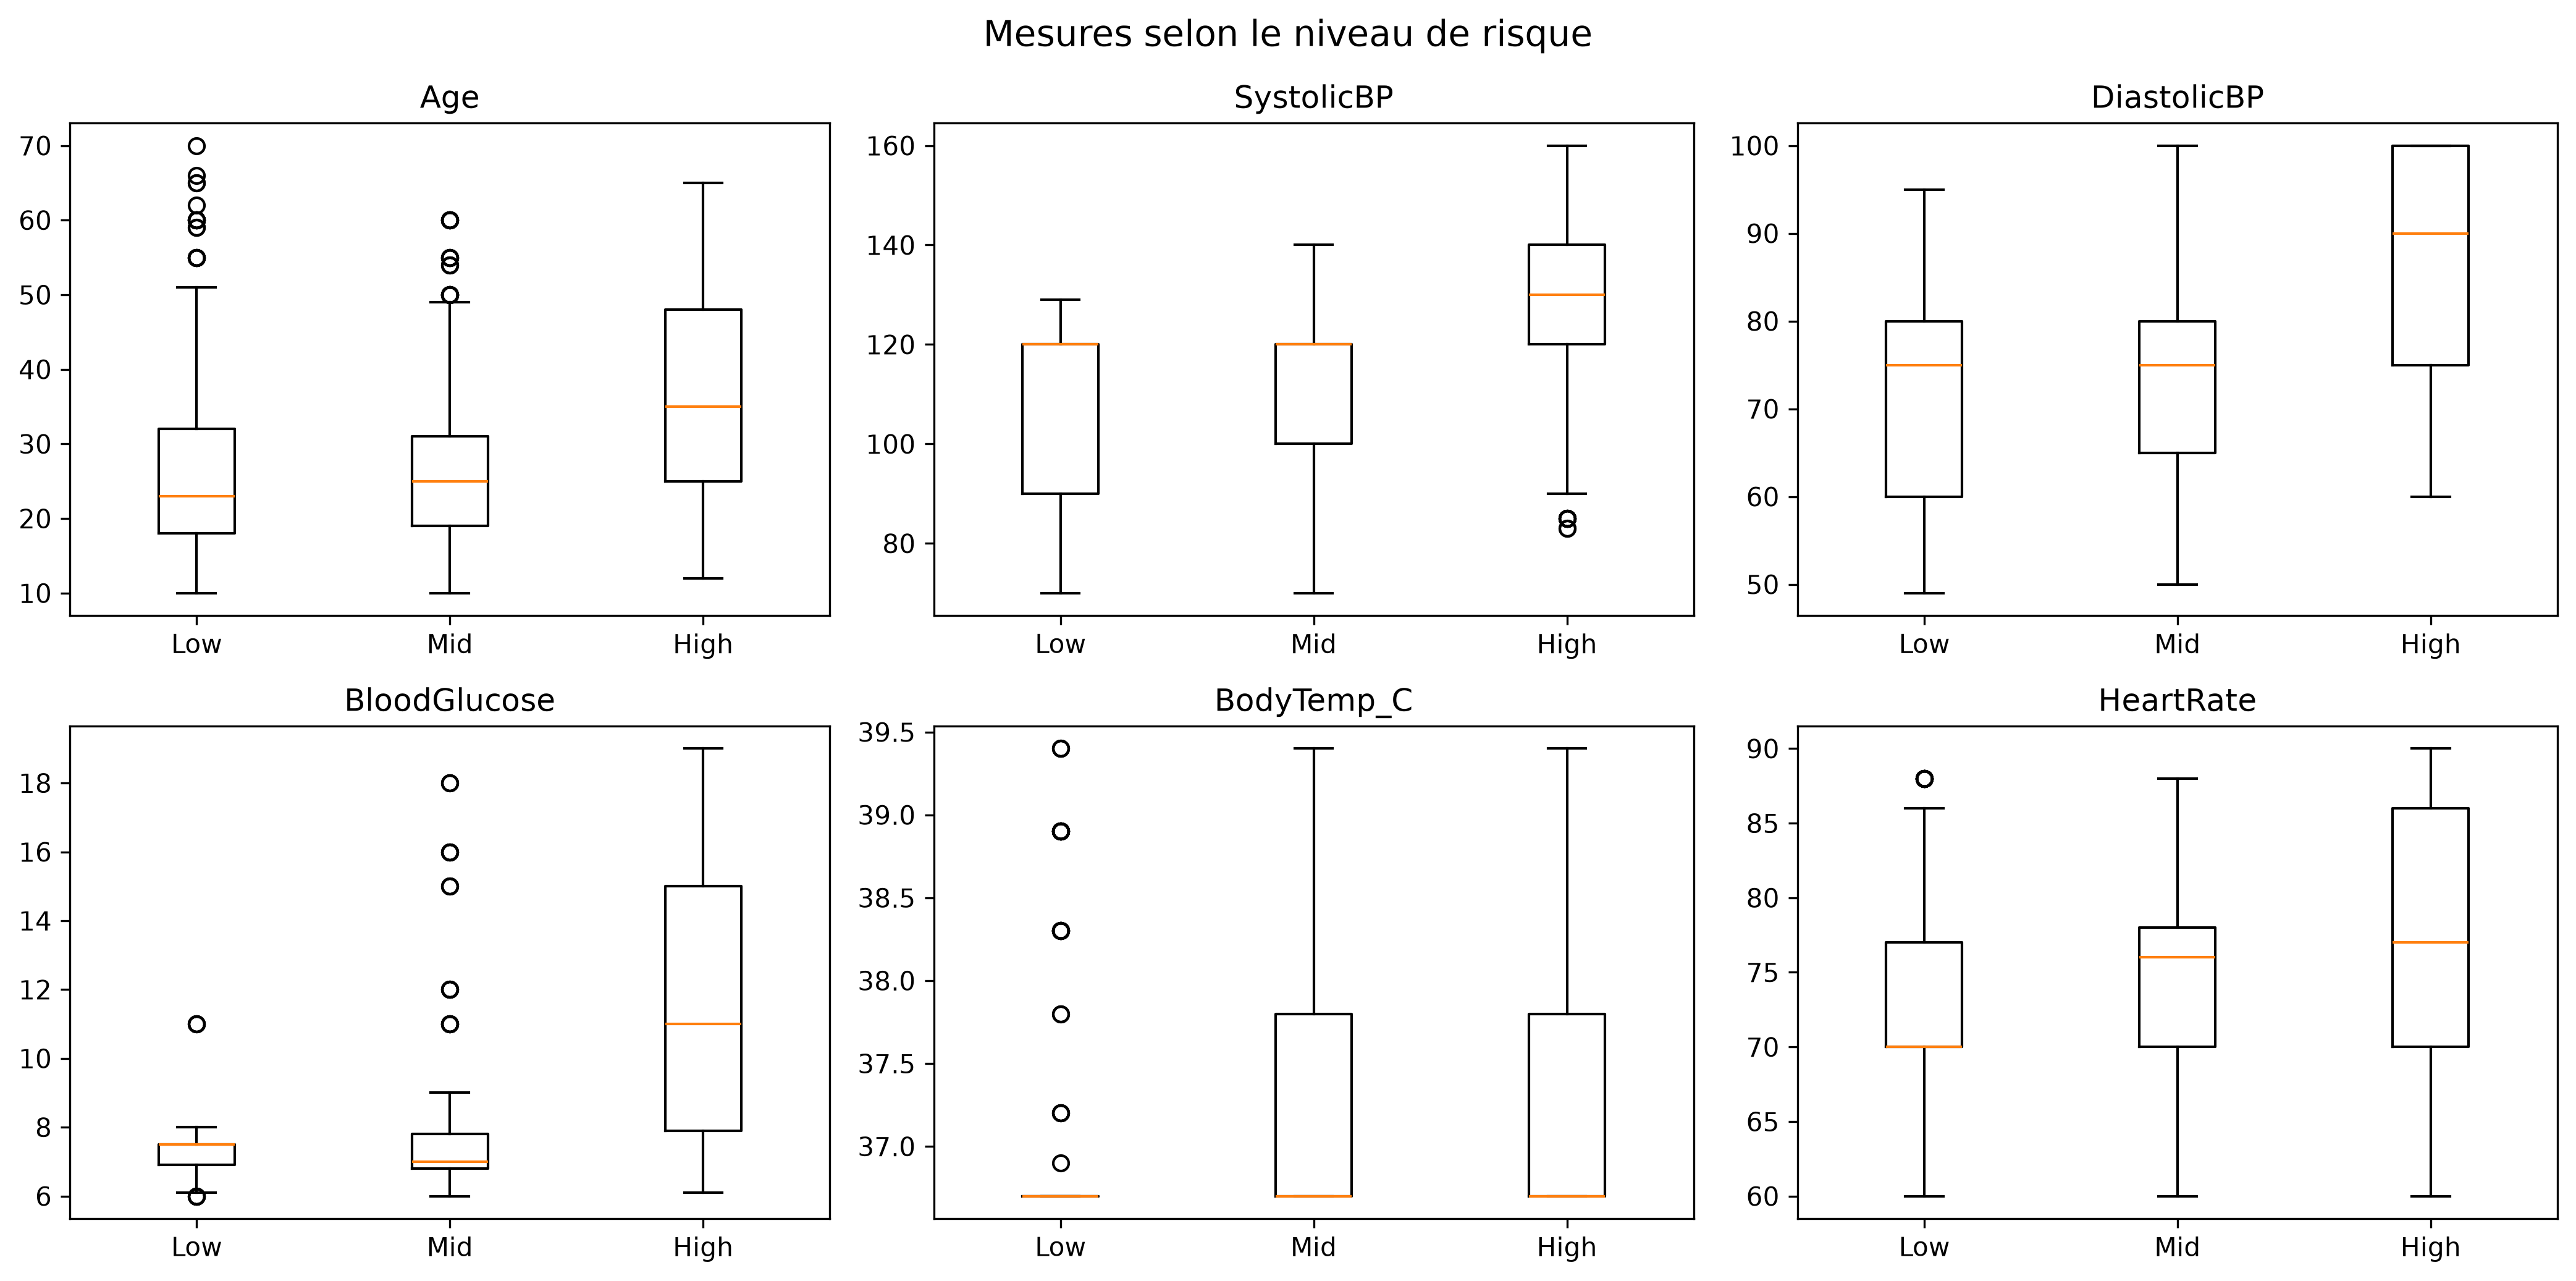

In [65]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, colonne in enumerate(mesures):
    donnees = [df_train_clean[df_train_clean["RiskLabel"] == r][colonne] for r in ordre]
    axes[i].boxplot(donnees)
    axes[i].set_xticks([1, 2, 3])
    axes[i].set_xticklabels(["Low", "Mid", "High"])
    axes[i].set_title(colonne)

plt.suptitle("Mesures selon le niveau de risque", fontsize=14)
plt.tight_layout()

plt.savefig(
    "./figures/mesure_selon_niveau_de_risque.png",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

## 5.4 Graphique 4 : Le risque selon la classe de glycémie
*(barres empilées, en %)*

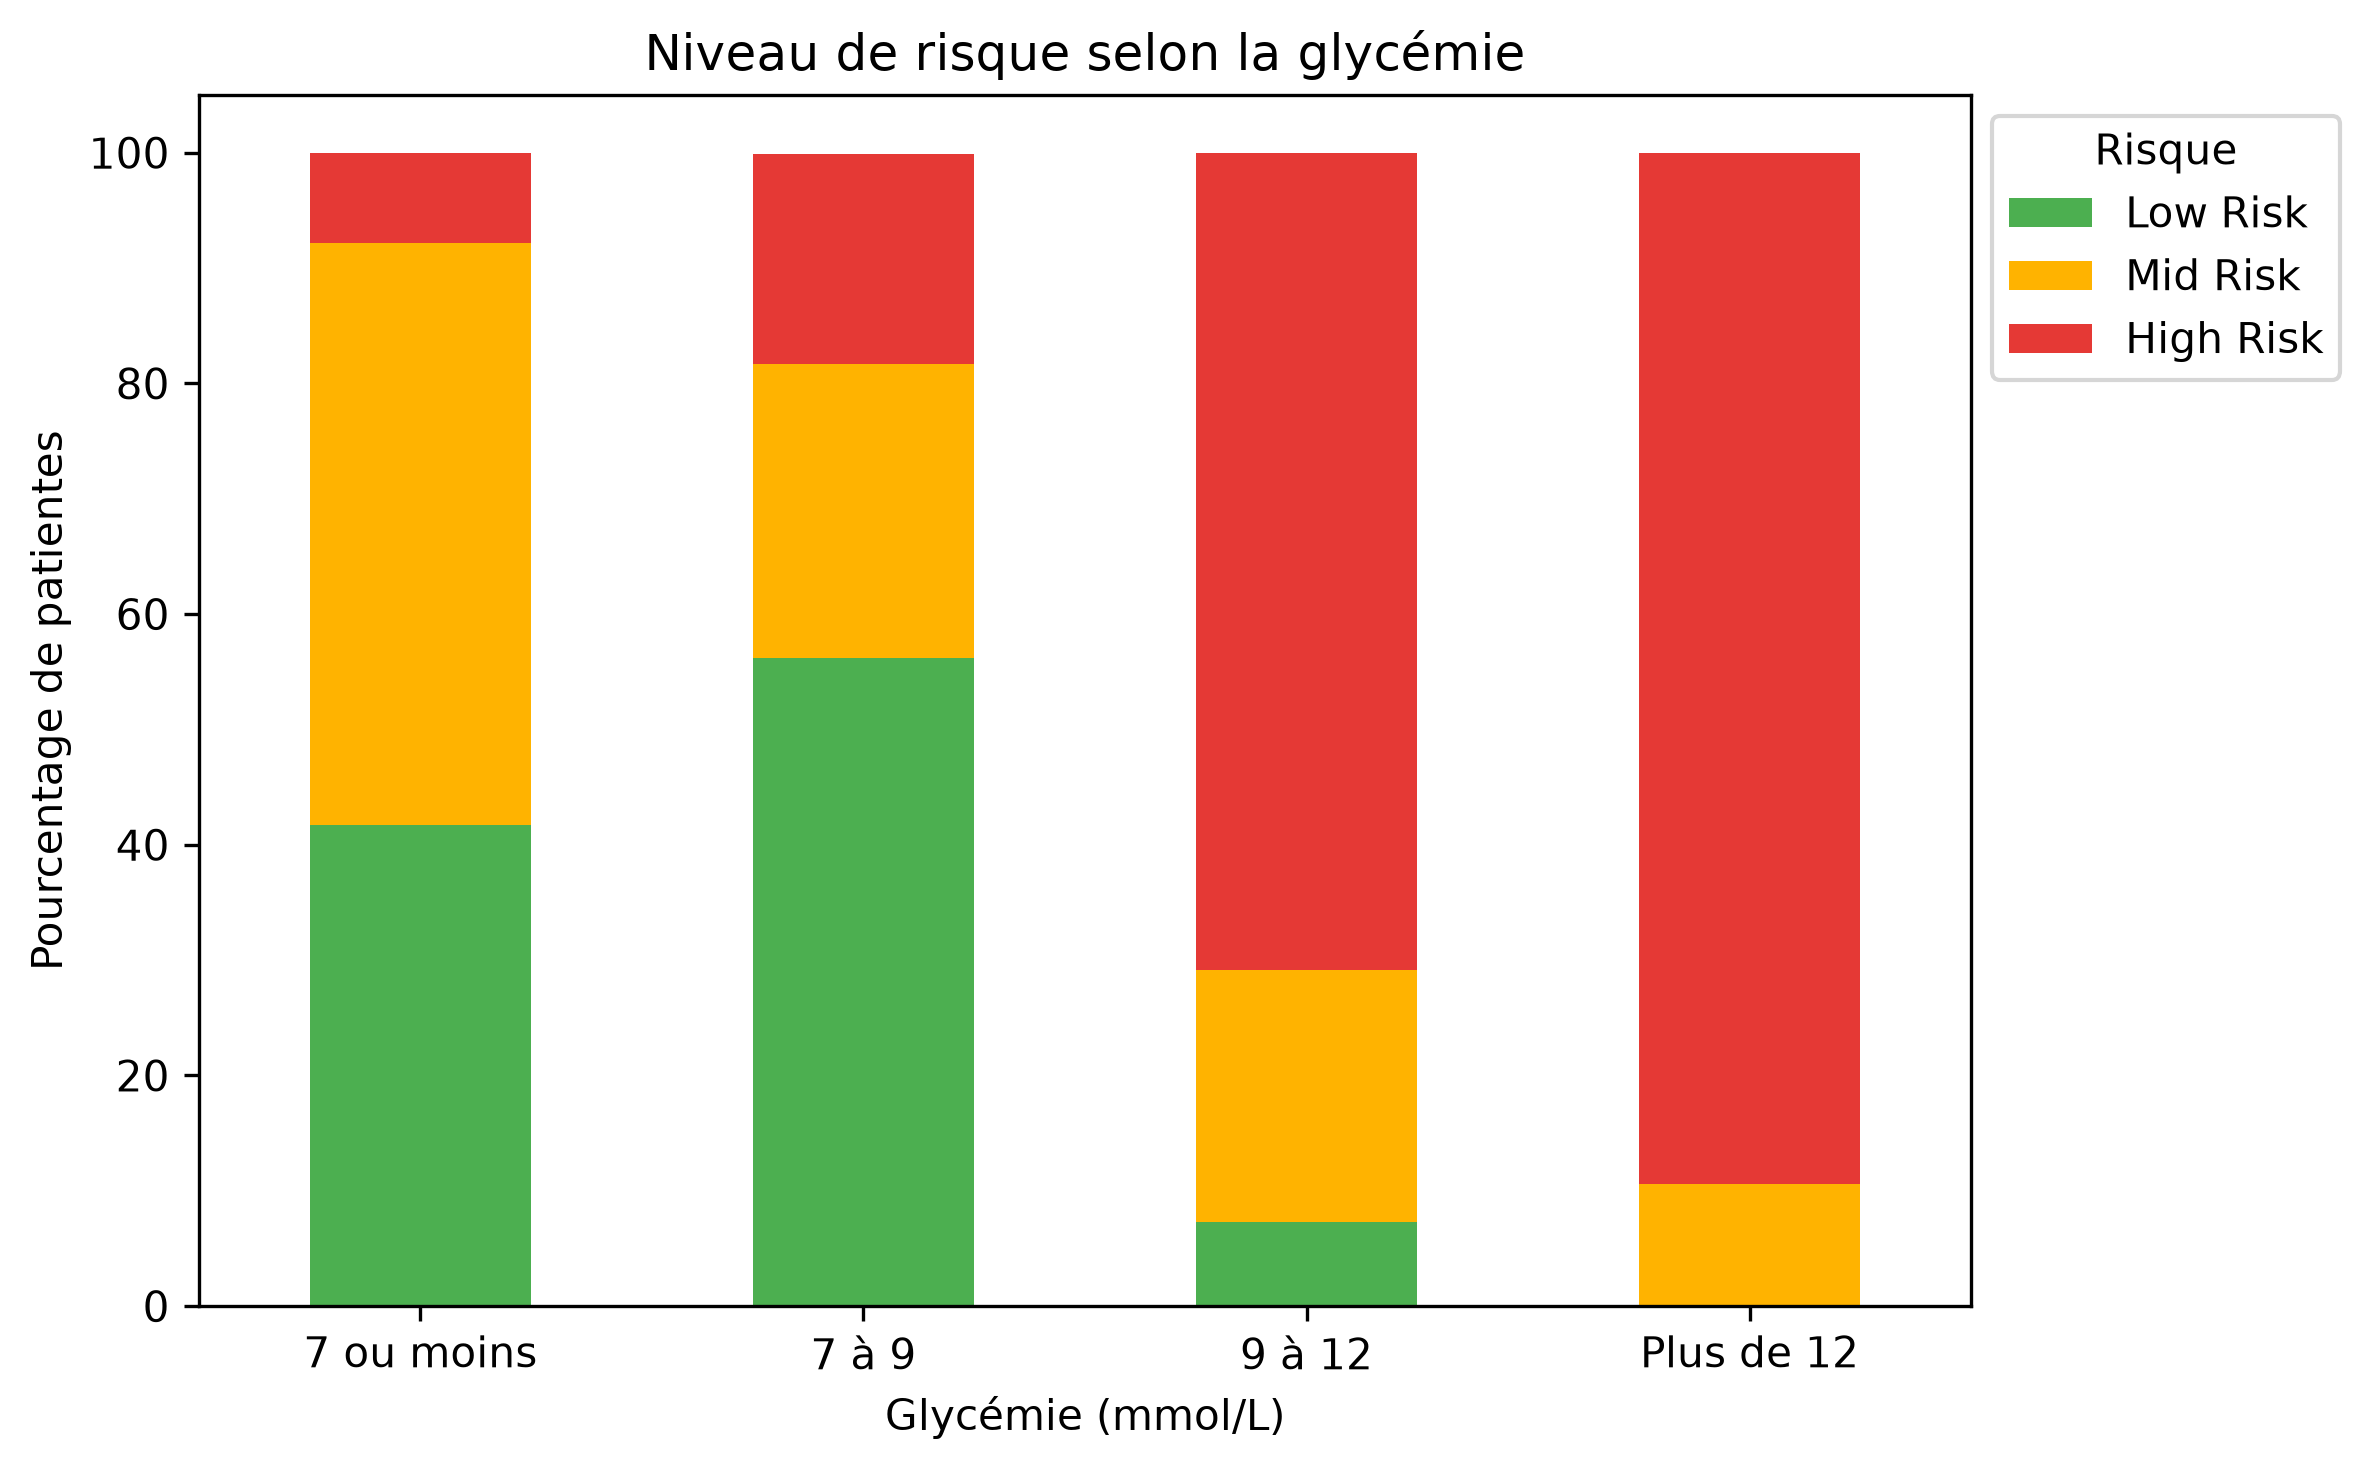

In [66]:
tableau_glycemie.plot(kind="bar", stacked=True, figsize=(8, 5),
color=[couleurs[r] for r in ordre])
plt.title("Niveau de risque selon la glycémie")
plt.xlabel("Glycémie (mmol/L)")
plt.ylabel("Pourcentage de patientes")
plt.xticks(rotation=0)
plt.legend(title="Risque", loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()

plt.savefig(
    "./figures/niveau_risque_selon_glycemie.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

## 5.5 Graphique 5 : Carte des corrélations

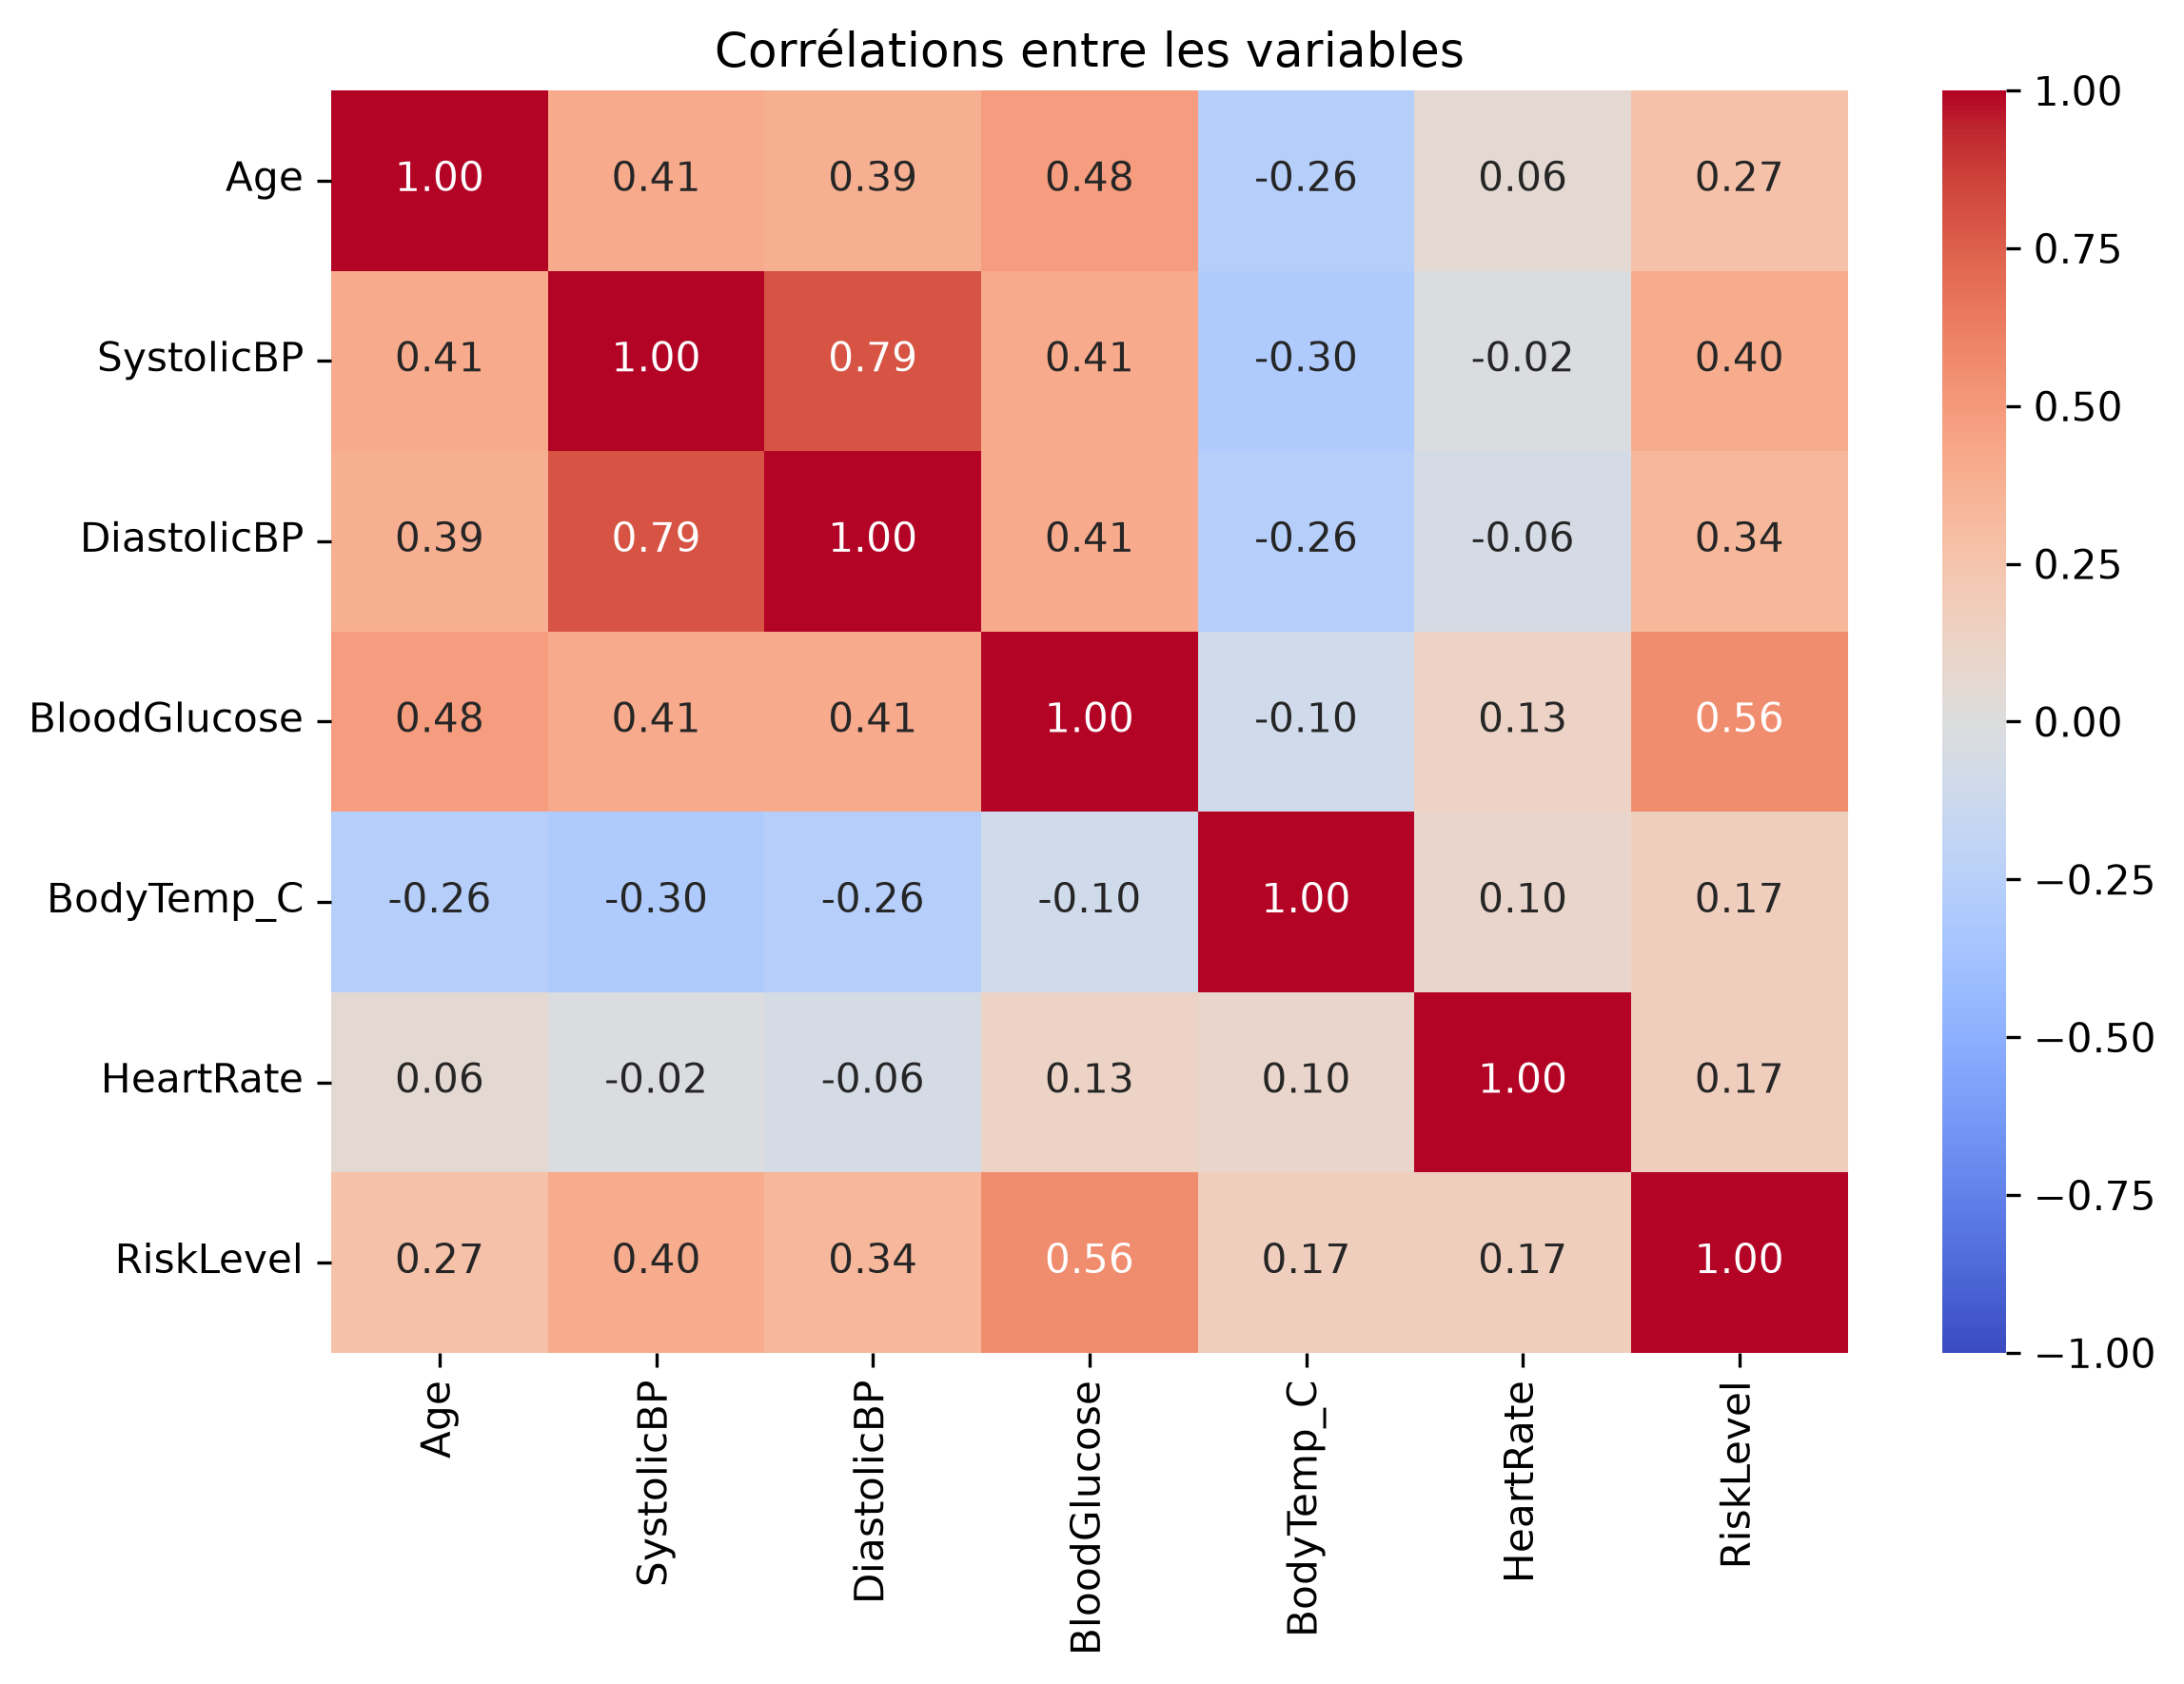

In [67]:

plt.figure(figsize=(8, 6))

sns.heatmap(
    matrice_correlations,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    fmt=".2f"
)

plt.title("Corrélations entre les variables")
plt.tight_layout()

plt.savefig(
    "./figures/matrice_correlation_variables.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()



## 5.6 Graphique 6 : Glycémie et tension systolique
*(nuage de points, une couleur par niveau de risque)*

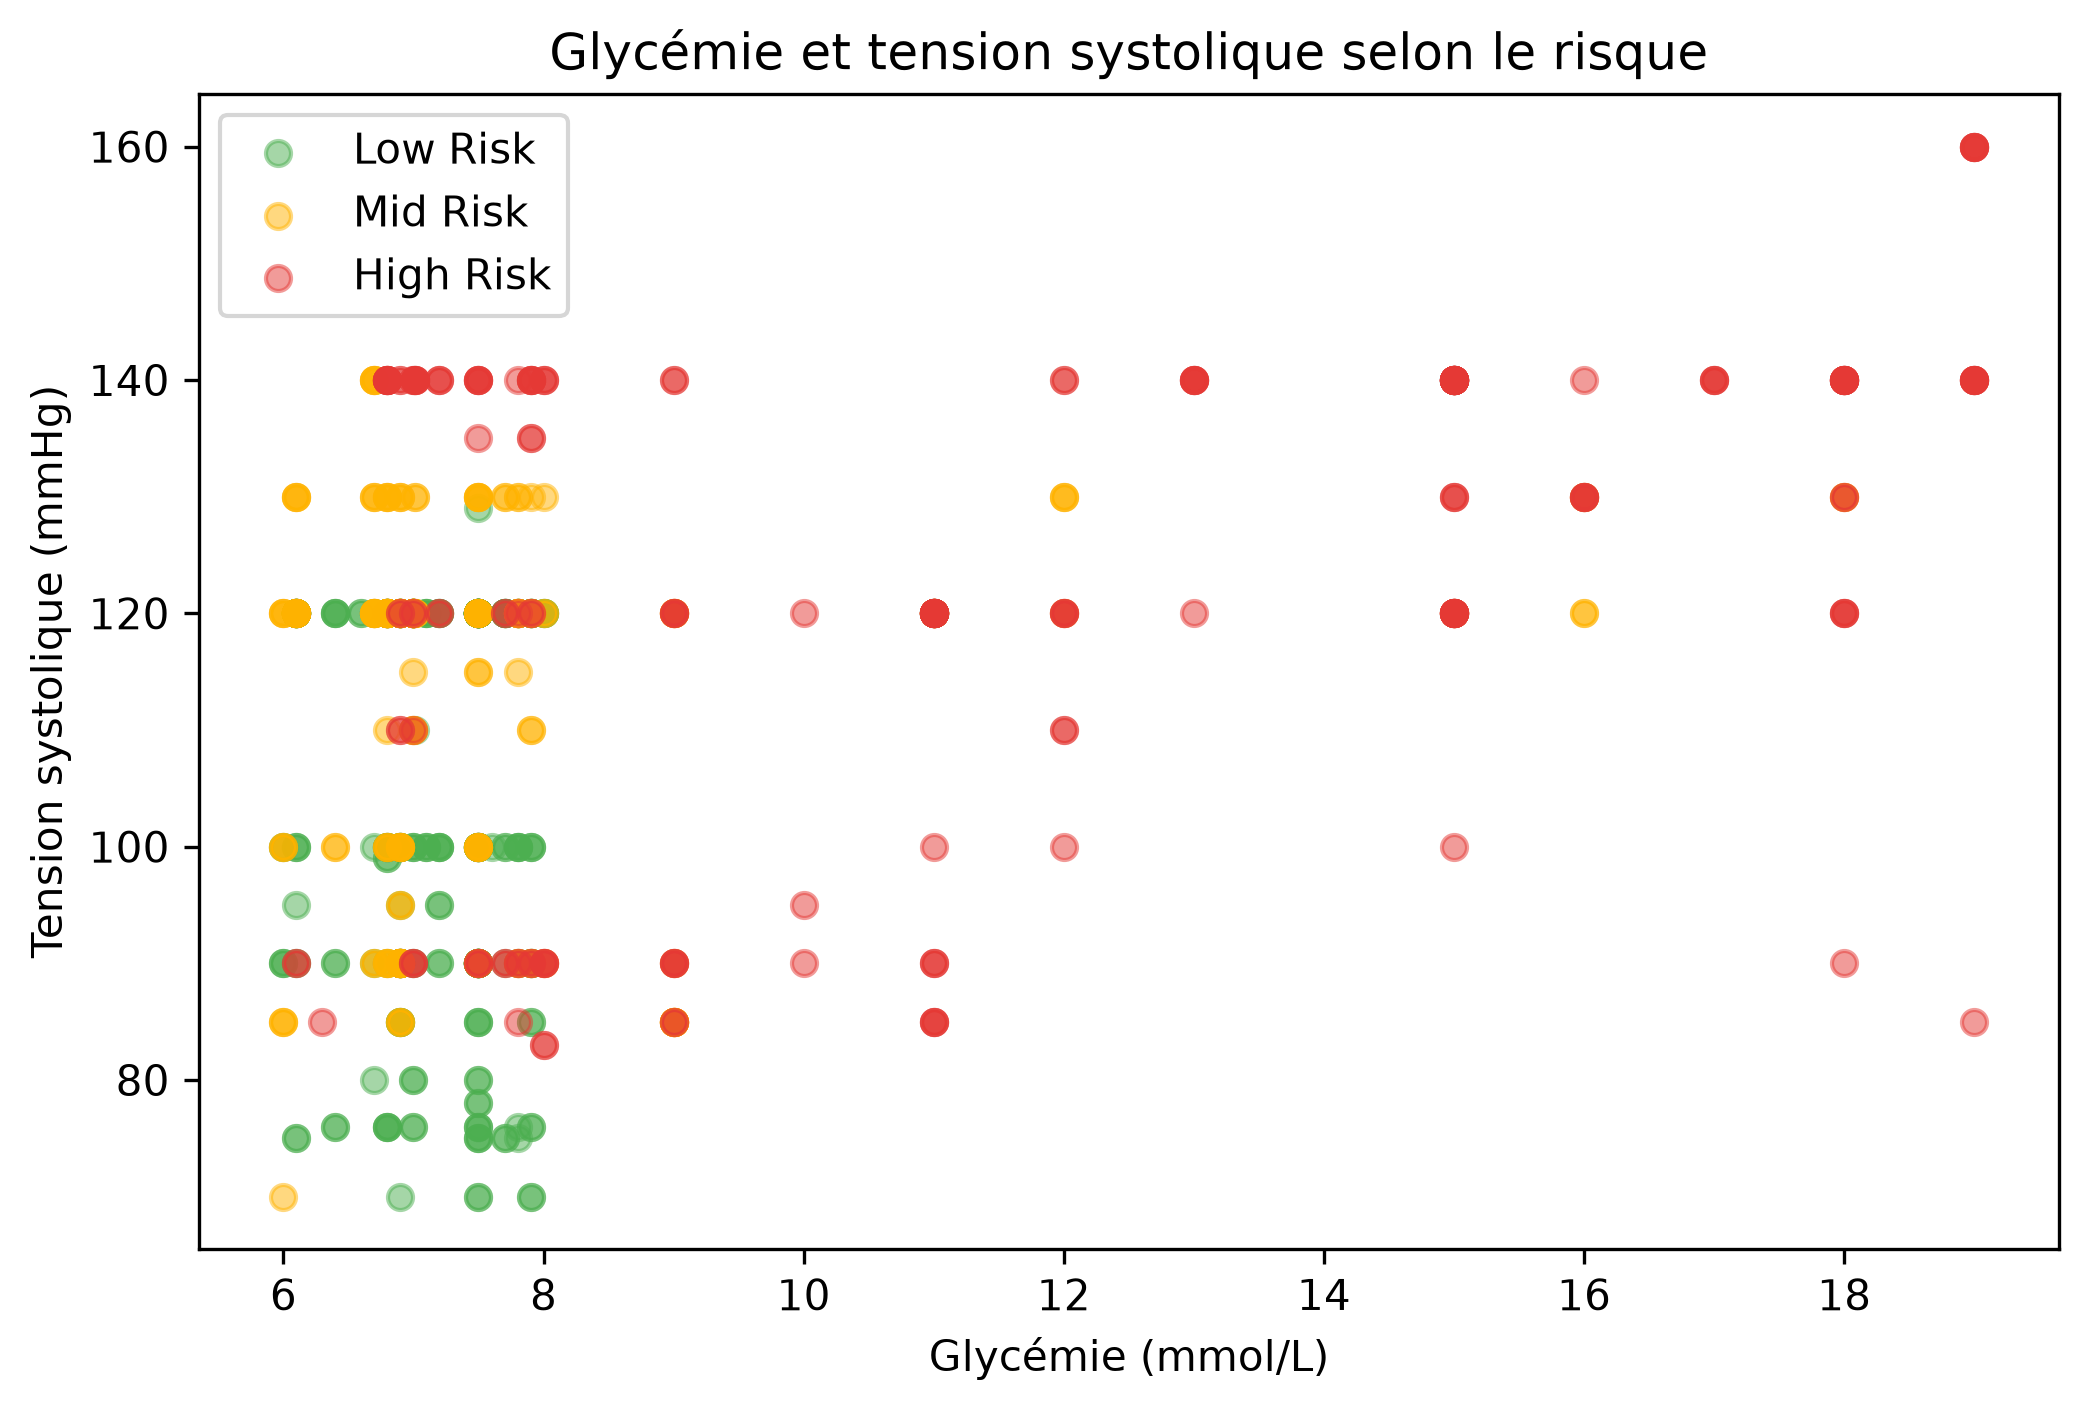

In [68]:
plt.figure(figsize=(8, 5))

for r in ordre:
    sous_tableau = df_train_clean[df_train_clean["RiskLabel"] == r]
    plt.scatter(sous_tableau["BloodGlucose"], sous_tableau["SystolicBP"],
                color=couleurs[r], label=r, alpha=0.5)

plt.title("Glycémie et tension systolique selon le risque")
plt.xlabel("Glycémie (mmol/L)")
plt.ylabel("Tension systolique (mmHg)")
plt.legend()

plt.savefig(
    "./figures/glycemie_tension_systolique_risque.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

## 5.7 Graphique 7 : Âge vs Glycémie
*(nuage de points)*

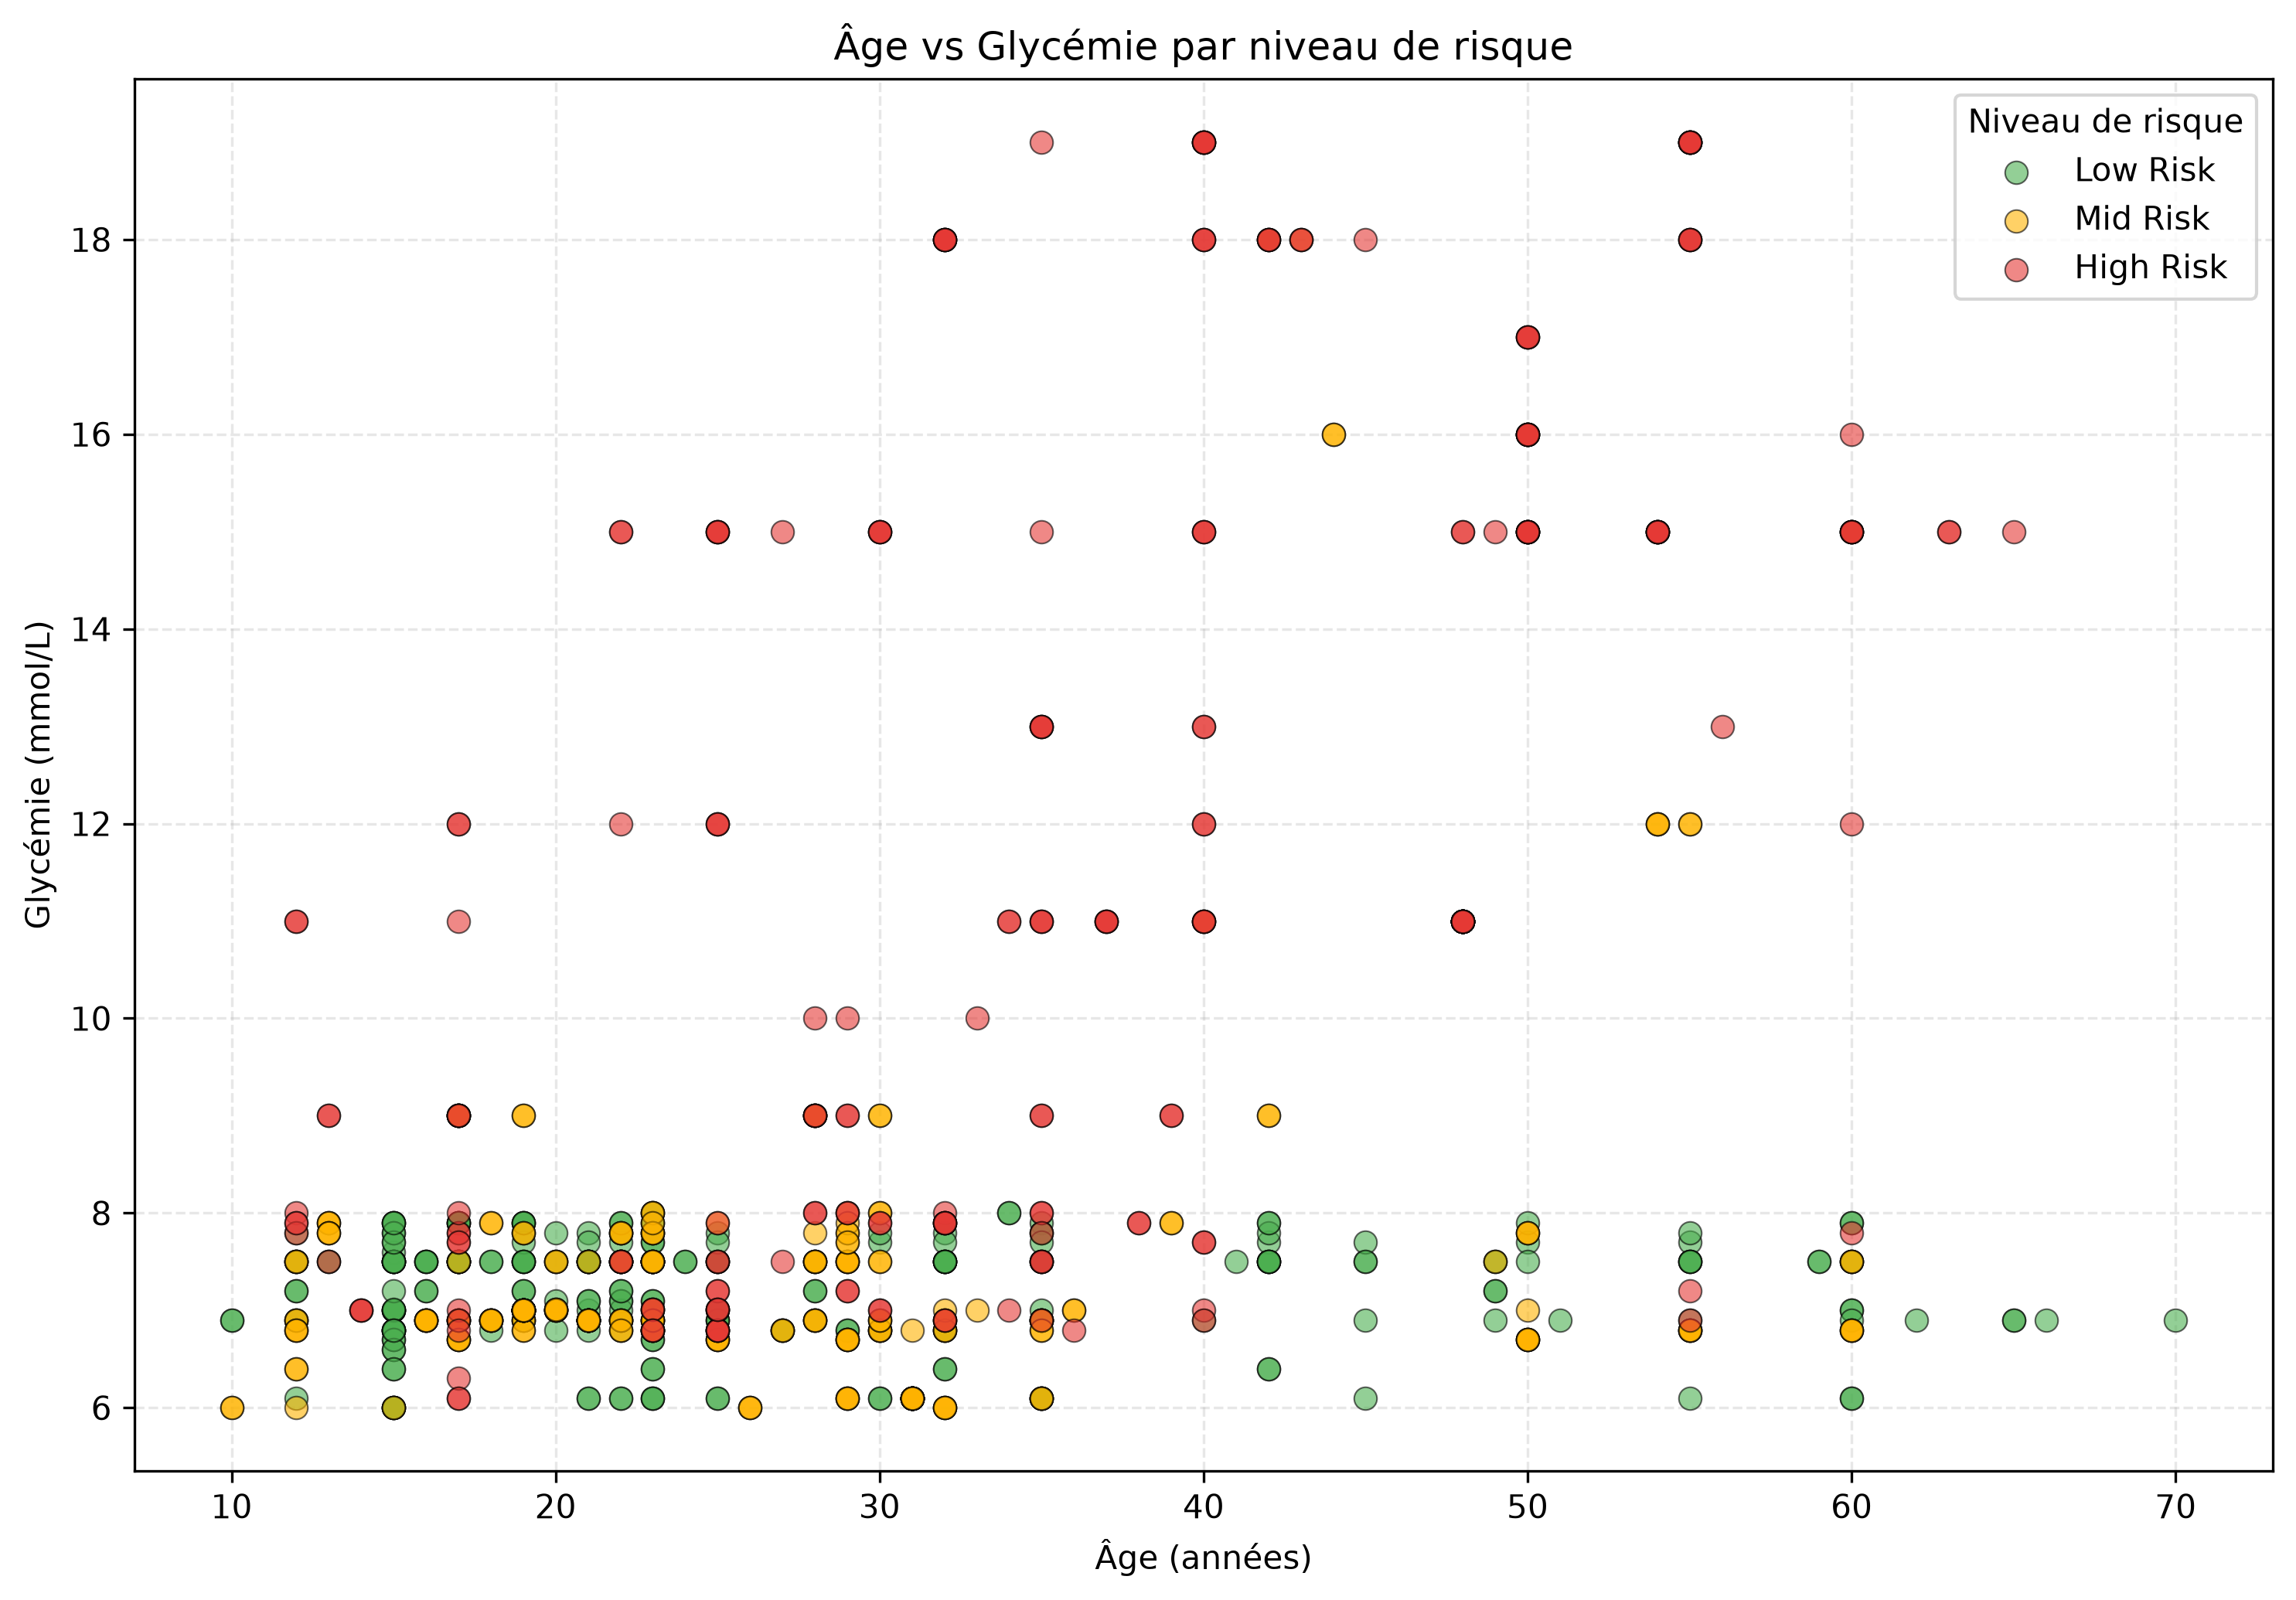

In [69]:
# scatter plot coloré par niveau de risque
fig, ax = plt.subplots(figsize=(10, 7))

for label in couleurs:
    subset = df_train_clean[df_train_clean["RiskLabel"] == label]

    ax.scatter(
        subset["Age"],
        subset["BloodGlucose"],
        c=couleurs[label],
        label=label,
        alpha=0.6,
        s=50,
        edgecolors="black",
        linewidth=0.5
    )

ax.set_xlabel("Âge (années)")
ax.set_ylabel("Glycémie (mmol/L)")
ax.set_title("Âge vs Glycémie par niveau de risque")

ax.legend(title="Niveau de risque")
ax.grid(alpha=0.3, linestyle="--")
ax.set_axisbelow(True)

plt.tight_layout()

plt.savefig(
    "./figures/scatter_age_glycemie.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()
plt.close()


## 5.8 Graphique 8 : `df_train` et `df_test` sont-ils comparables ?

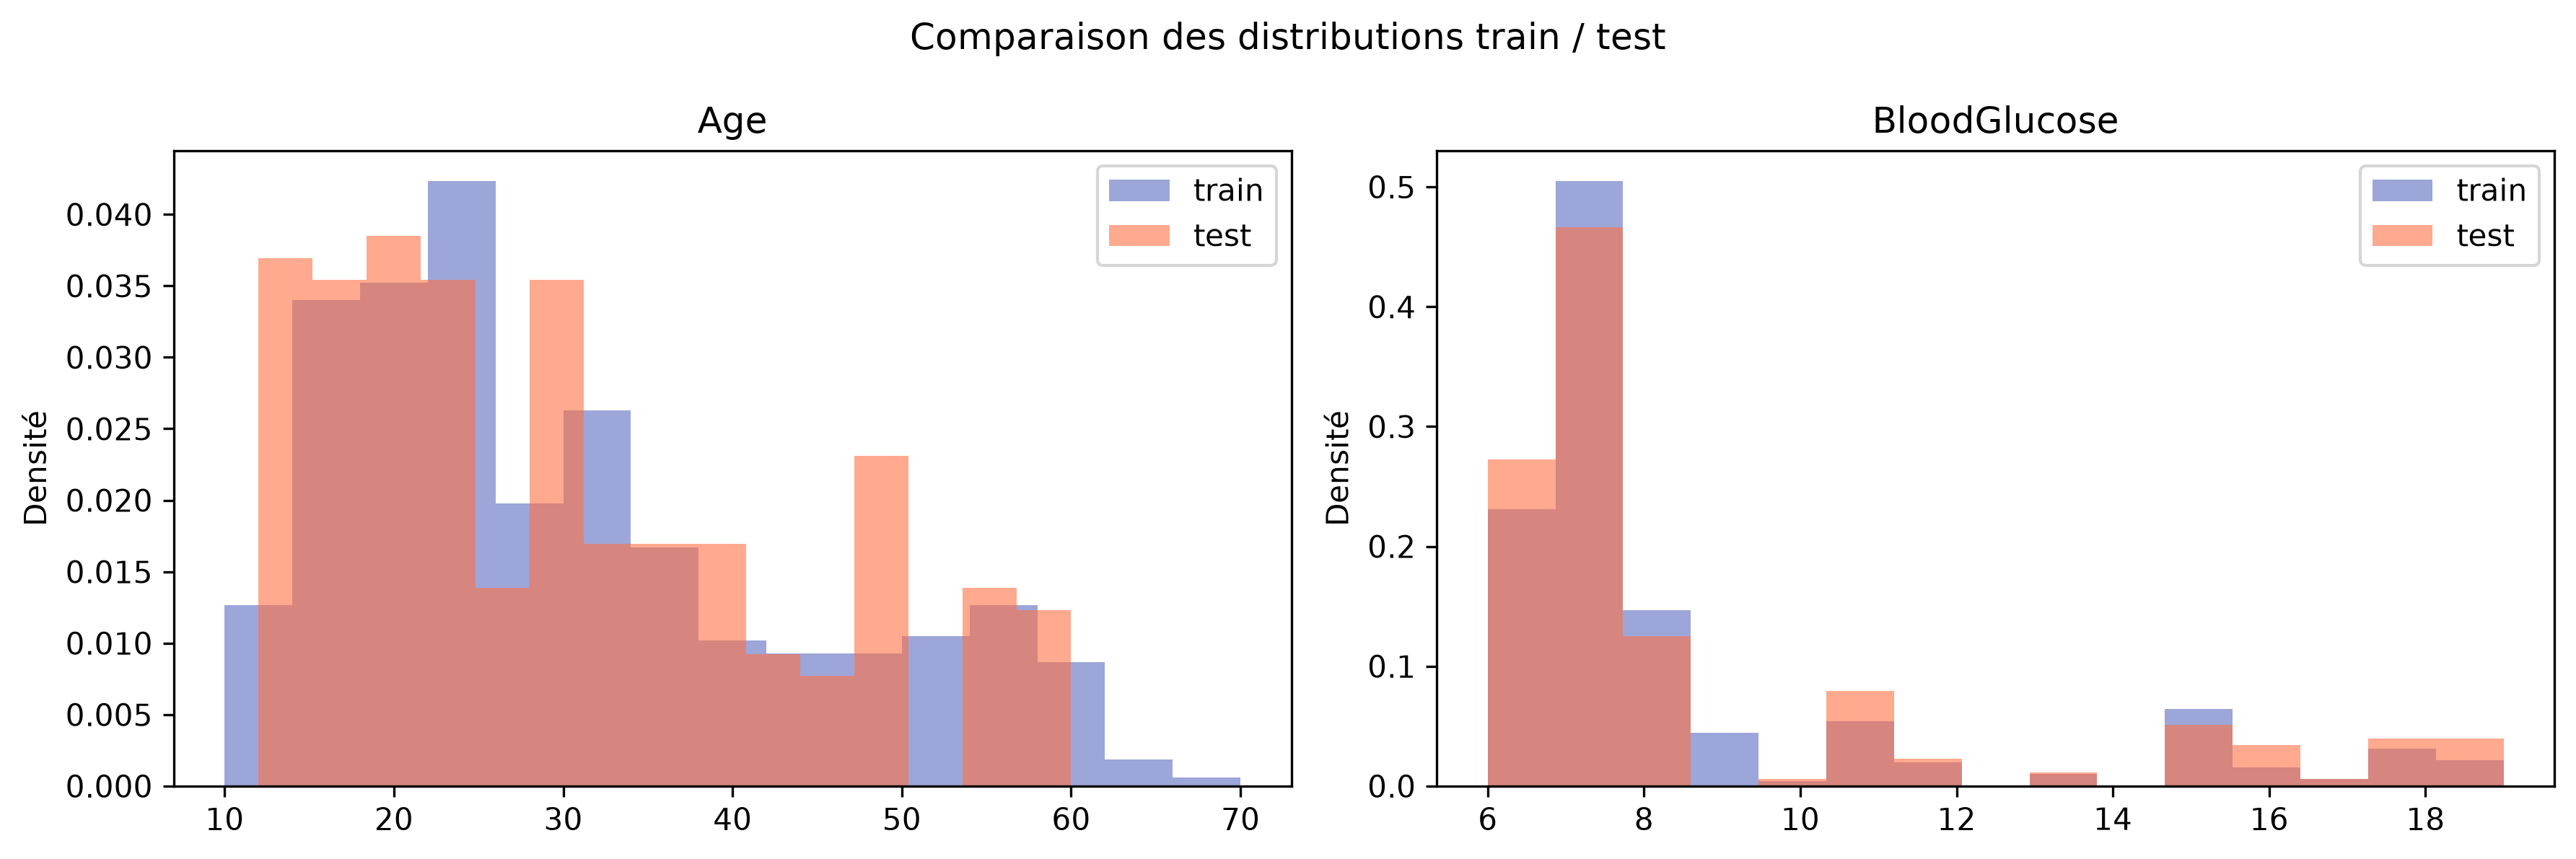

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, colonne in zip(axes, ["Age", "BloodGlucose"]):
    ax.hist(df_train_clean[colonne], bins=15, alpha=0.6, density=True, label="train", color="#5C6BC0")
    ax.hist(df_test_clean[colonne], bins=15, alpha=0.6, density=True, label="test", color="#FF7043")
    ax.set_title(colonne)
    ax.set_ylabel("Densité")
    ax.legend()

plt.suptitle("Comparaison des distributions train / test")
plt.tight_layout()

plt.savefig(
    "./figures/comparaison_distributions_test_vs_train.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()


---

# 6. CONCLUSION

## 6.1 Résumé

### Répartition des niveaux de risque

Les trois niveaux sont présents de façon assez équilibrée : environ **40 % de risque faible**, **33 % de risque moyen** et **27 % de risque élevé**. Aucune classe n'est quasi absente, ce qui rend la comparaison entre groupes possible.

### Quelles mesures distinguent le mieux les niveaux de risque ?

- **La glycémie est le facteur le plus lié au risque** (corrélation ≈ 0,56). Sa moyenne est d'environ 7,2 mmol/L pour le risque faible, 7,7 pour le risque moyen, mais **près de 12 pour le risque élevé**. Le saut se fait surtout entre « moyen » et « élevé ». Au-dessus de 9 mmol/L, la majorité des patientes sont à risque élevé (environ 71 %), et au-dessus de 12 mmol/L presque toutes (environ 89 %).
- **La pression artérielle** est le deuxième facteur : la pression systolique moyenne passe d'environ 106 à 113 puis 124 mmHg (corrélation ≈ 0,40) et la diastolique d'environ 72 à 74 puis 85 mmHg. À partir de **140 mmHg de systolique, 95 % des patientes sont à risque élevé**.
- **L'âge** joue aussi (corrélation ≈ 0,27) : l'âge moyen est d'environ 27 ans pour le risque faible et 28 ans pour le risque moyen, mais **près de 37 ans pour le risque élevé**.
- **La température corporelle et la fréquence cardiaque** ont un lien plus faible (corrélation ≈ 0,17 chacune). Les patientes à risque faible ont une température un peu plus basse (environ 0,3 °C de moins) et une fréquence cardiaque un peu plus basse (73 contre 76 bpm).

### Lecture des graphiques

- Les **boîtes à moustaches** confirment les moyennes : pour la glycémie, la boîte « High » est nettement au-dessus des deux autres, alors que pour la fréquence cardiaque les trois boîtes se chevauchent beaucoup.
- Le **nuage de points** montre que les patientes à risque élevé (rouge) se regroupent en haut à droite : glycémie et pression élevées en même temps.
- La **carte des corrélations** montre que les variables sont aussi liées entre elles : la pression systolique et diastolique sont très liées (≈ 0,79), et l'âge est lié à la glycémie et à la pression. Les facteurs de risque se **cumulent** donc.
- Le **scatter plot Âge vs Glycémie** :

  | Niveau | Observation |
  |---|---|
  | **Low Risk** (vert) | Réparti sur tous les âges (10 à 70 ans), avec une glycémie presque toujours basse |
  | **Mid Risk** (orange) | Proche de Low Risk : glycémie majoritairement basse, quelques valeurs élevées |
  | **High Risk** (rouge) | Glycémie le plus souvent supérieure à 9 mmol/L, à tous les âges, y compris chez des femmes jeunes |

  Il montre que c'est surtout la **glycémie** qui sépare les groupes, quel que soit l'âge : l'âge seul ne permet pas de distinguer les niveaux de risque.

### Comparaison df_train / df_test

Les histogrammes de l'âge et de la glycémie pour `df_train` et `df_test` sont proches : les deux jeux de données ont la même structure, donc ce qu'on observe sur `df_train` a de bonnes chances de se retrouver sur `df_test`. Cette comparaison ne porte que sur ces deux variables.

### Précautions

- Une **corrélation n'est pas une causalité** : on constate un lien, on ne prouve pas qu'une mesure *cause* le risque.
- Certaines mesures sont très répétitives (la température vaut 98 °F pour environ 80 % des lignes), ce qui limite leur pouvoir d'analyse.
- La correspondance 0/1/2 = Low/Mid/High est une **hypothèse** (non précisée dans `metadata.csv`).
- Le niveau de risque est une variable ordonnée (0/1/2) : la corrélation de Pearson donne donc seulement une indication approximative.
- L'âge varie de 10 à 70 ans dans les données ; ces valeurs extrêmes n'ont pas été vérifiées.

## 6.2 Principaux résultats

De l'analyse des données, il ressort que :

1. Le niveau de risque est surtout associé à la **glycémie**, puis à la **pression artérielle**, puis à l'**âge**.
2. Les patientes à **risque élevé** se distinguent clairement : glycémie moyenne proche de 12 mmol/L, tension plus haute, âge moyen plus élevé.
3. Les femmes à risque élevé sont en moyenne plus âgées (environ 37 ans, contre 27 à 28 ans pour les risques faible et moyen).
4. La **température** et la **fréquence cardiaque** apportent peu d'information.
5. Les jeux `df_train` et `df_test` paraissent **comparables** sur l'âge et la glycémie.

## 6.3 Limites de l'étude

1. **Nature observationnelle** : nous ne pouvons établir que des associations, pas des relations de cause à effet.
2. **Biais potentiel** : les données proviennent de zones rurales du Bangladesh, limitant la généralisation.
3. **Variables manquantes** : d'autres facteurs (parité, antécédents, IMC) pourraient être pertinents.
4. **Données transversales** : pas de suivi longitudinal des patientes.
5. **Classification du risque** : les critères exacts de classification ne sont pas documentés.

## 6.4 Recommandations pour des analyses futures

1. **Approche prédictive** : développer un modèle de machine learning pour prédire le niveau de risque.
2. **Variables supplémentaires** : intégrer des données sur la parité, l'IMC, les antécédents médicaux.
3. **Analyse temporelle** : suivi longitudinal des grossesses.
4. **Validation externe** : tester les résultats sur d'autres populations.
5. **Seuils cliniques** : valider les seuils identifiés avec des experts médicaux.